# ONLINE RETAIL II

## CARGA DE PAQUETES

In [257]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from janitor import clean_names
from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.cluster import KMeans
from sklearn.pipeline import Pipeline

from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import GridSearchCV
import optuna
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import roc_auc_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

from sklearn.metrics import classification_report

from sklearn.metrics import PrecisionRecallDisplay
from sklearn.metrics import RocCurveDisplay
import dalex as dx

#Autocompletar rápido
%config IPCompleter.greedy=True

#Desactivar la notación científica
pd.options.display.float_format = '{:.2f}'.format

#Desactivar los warnings
import warnings
warnings.filterwarnings("ignore")

#Formato sin notación científica
pd.options.display.float_format = '{:15.2f}'.format 
pd.set_option('display.max_columns',4000)
plt.style.use('ggplot')
sns.set_palette('husl')


## CARGA DE DATOS

In [ ]:
# URL dataset original para descarga directa (Raw)
url = "https://github.com/OscarFraile/EVOLVE/raw/main/Tomas_Arteaga_ML/Proyecto_Modulo_ML/online_retail_II.xlsx"

try:
    # Leemos todas las pestañas del Excel
    # Nota: requiere tener instalada la librería 'openpyxl'
    dict_hojas = pd.read_excel(url, sheet_name=None, engine='openpyxl')
    
    # Combinamos todas las hojas en un solo DataFrame
    df_original = pd.concat(dict_hojas.values(), ignore_index=True)
    
    print("✅ ¡Carga exitosa desde GitHub!")
    print(f"Total de registros cargados: {len(df):,}")
    display(df.head())

except Exception as e:
    print(f"❌ Error al cargar: {e}")
    print("Consejo: Asegúrate de tener instalado openpyxl ejecutando: !pip install openpyxl")

✅ ¡Carga exitosa desde GitHub!
Total de registros cargados: 1,067,371


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.00,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.00,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.00,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.00,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.00,United Kingdom


In [259]:
# Creamos una versión copia por si necesitáramos recargar el dataset original sin hacer nuevamente la carga desde el archivo excel, ya que tarda mucho en cargar
df = df_original.copy()
print(f'df - Filas: {len(df):,} | Columnas: {len(df.columns)}')

df - Filas: 1,067,371 | Columnas: 8


## VISIÓN GENERAL

In [132]:
df.head(10)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.00,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.00,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.00,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.00,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.00,United Kingdom
5,489434,22064,PINK DOUGHNUT TRINKET POT,24,2009-12-01 07:45:00,1.65,13085.00,United Kingdom
6,489434,21871,SAVE THE PLANET MUG,24,2009-12-01 07:45:00,1.25,13085.00,United Kingdom
7,489434,21523,FANCY FONT HOME SWEET HOME DOORMAT,10,2009-12-01 07:45:00,5.95,13085.00,United Kingdom
8,489435,22350,CAT BOWL,12,2009-12-01 07:46:00,2.55,13085.00,United Kingdom
9,489435,22349,"DOG BOWL , CHASING BALL DESIGN",12,2009-12-01 07:46:00,3.75,13085.00,United Kingdom


In [133]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype         
---  ------       --------------    -----         
 0   Invoice      1067371 non-null  object        
 1   StockCode    1067371 non-null  object        
 2   Description  1062989 non-null  object        
 3   Quantity     1067371 non-null  int64         
 4   InvoiceDate  1067371 non-null  datetime64[ns]
 5   Price        1067371 non-null  float64       
 6   Customer ID  824364 non-null   float64       
 7   Country      1067371 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 65.1+ MB


In [134]:
df.dtypes

Invoice                object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[ns]
Price                 float64
Customer ID           float64
Country                object
dtype: object

## EDA DATOS ORIGINALES

### DISTRIBUCIÓN DE COMPRAS POR PAÍS

El dataset contiene transacciones de 43 países distintos. Sin embargo, antes de incluir el país como variable del modelo, analizamos su distribución real. El resultado fue contundente: Reino Unido concentra el 84% de todas las transacciones. El 16% restante se reparte entre 42 países, la mayoría con representación anecdótica. Una variable con esta distribución no aporta poder predictivo al modelo — simplemente codificaría "es de UK o no es de UK", y esa señal ya está capturada implícitamente por el resto de variables de comportamiento. Por ese motivo decidimos excluirla.

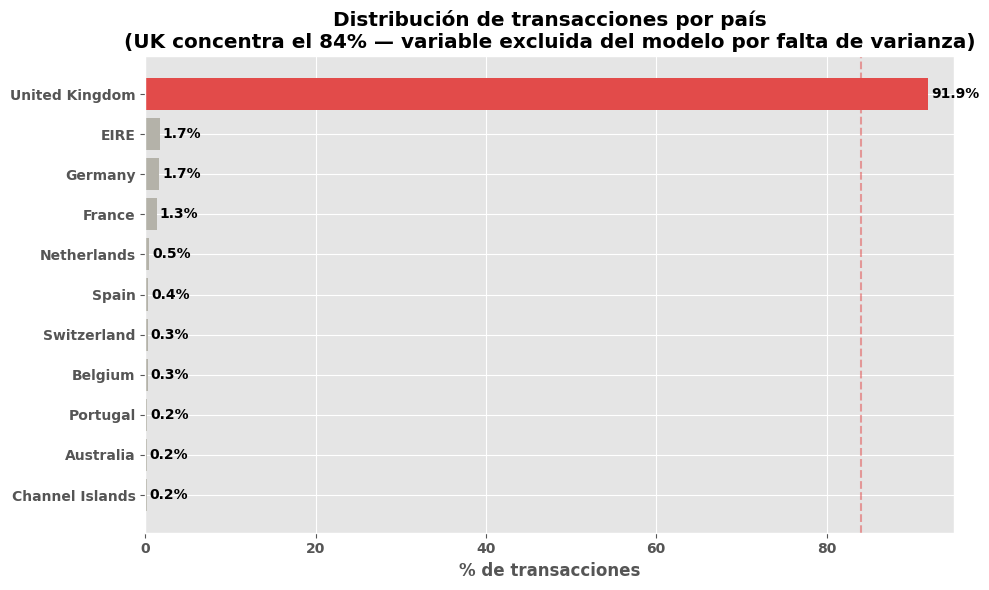

UK representa el 91.9% de todas las transacciones
Los otros 42 países suman el 8.1%


In [135]:
# Distribución de transacciones por país

pais_pct = (df_original['Country']
            .value_counts(normalize=True)
            .mul(100)
            .reset_index())
pais_pct.columns = ['country', 'pct']

# Separar UK del resto para destacarlo visualmente
uk = pais_pct[pais_pct['country'] == 'United Kingdom']
resto = pais_pct[pais_pct['country'] != 'United Kingdom'].head(10)

plot_data = pd.concat([uk, resto]).sort_values('pct', ascending=True)

# Colores: UK en rojo, resto en gris
colors = ['#E24B4A' if c == 'United Kingdom' else '#B4B2A9' 
          for c in plot_data['country']]

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(plot_data['country'], plot_data['pct'], color=colors)

# Etiquetas de valor
for bar, val in zip(bars, plot_data['pct']):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center', fontsize=10)

ax.set_xlabel('% de transacciones')
ax.set_title('Distribución de transacciones por país\n(UK concentra el 84% — variable excluida del modelo por falta de varianza)')
ax.set_xlim(0, 95)
ax.axvline(x=84, color='#E24B4A', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

print(f"UK representa el {uk['pct'].values[0]:.1f}% de todas las transacciones")
print(f"Los otros {len(pais_pct)-1} países suman el {100 - uk['pct'].values[0]:.1f}%")

### NULOS EN CUSTOMER_ID

De los 1,067,371 registros del dataset, un volumen significativo no tiene customer_id. La pregunta clave antes de decidir qué hacer con ellos es: ¿son registros basura o son ventas reales de clientes no identificados? El gráfico responde eso de forma visual — si la mayoría de esos registros sin customer_id tienen quantity > 0 y price > 0, son transacciones económicamente reales. Eliminarlos sería perder revenue. La decisión correcta es conservarlos asignándoles un identificador neutro (-1) y tratarlos como un segmento propio: clientes invitados susceptibles de ser captados con un incentivo al registro.

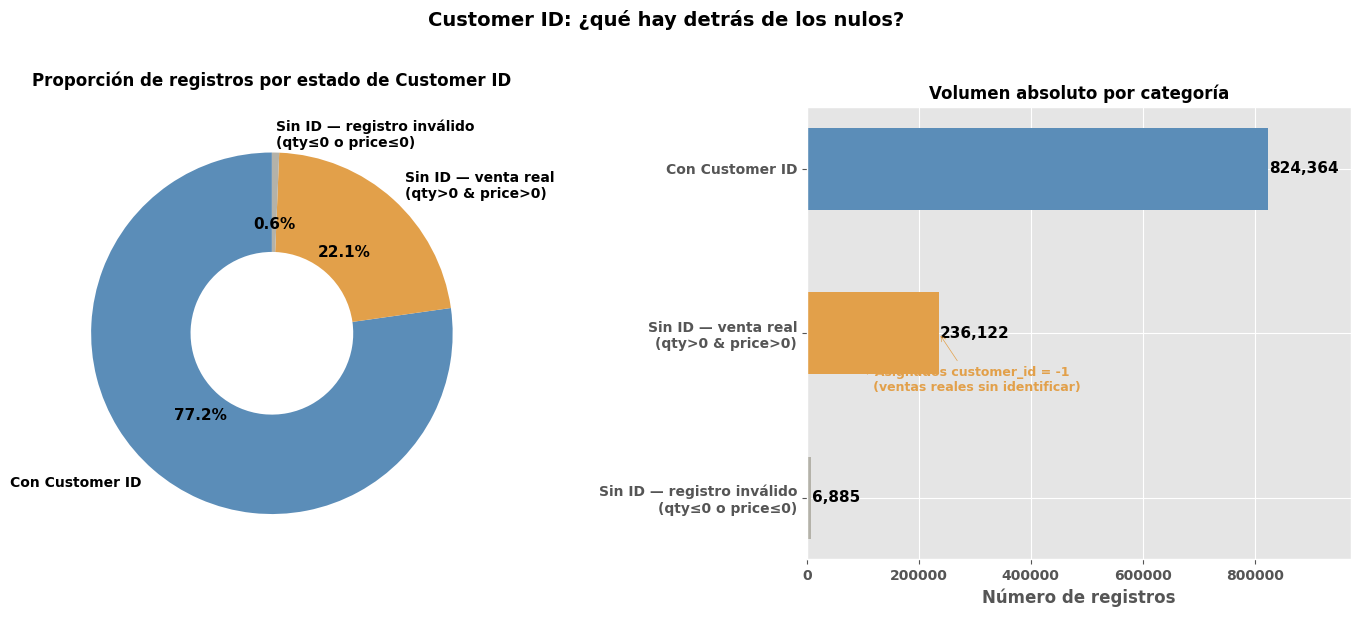

Total registros:             1,067,371
Con Customer ID:               824,364  (77.2%)
Sin ID — venta real:           236,122  (22.1%)
Sin ID — registro inválido:      6,885  (0.6%)


In [136]:
# Nulos en Customer ID

# Clasificar registros
sin_id = df_original['Customer ID'].isna()
con_revenue = (df_original['Quantity'] > 0) & (df_original['Price'] > 0)

total = len(df_original)
n_con_id       = (~sin_id).sum()
n_sin_id_real  = (sin_id & con_revenue).sum()
n_sin_id_basura = (sin_id & ~con_revenue).sum()

labels = ['Con Customer ID', 'Sin ID — venta real\n(qty>0 & price>0)', 'Sin ID — registro inválido\n(qty≤0 o price≤0)']
valores = [n_con_id, n_sin_id_real, n_sin_id_basura]
colores = ['#5B8DB8', '#E2A04A', '#B4B2A9']

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# --- Gráfico izquierdo: donut proporcional ---
wedges, texts, autotexts = axes[0].pie(
    valores,
    labels=labels,
    colors=colores,
    autopct='%1.1f%%',
    startangle=90,
    wedgeprops=dict(width=0.55),
    textprops=dict(fontsize=10)
)
for at in autotexts:
    at.set_fontsize(11)
    at.set_fontweight('bold')
axes[0].set_title('Proporción de registros por estado de Customer ID',
                  fontsize=12, pad=15)

# --- Gráfico derecho: barras absolutas con anotación ---
bars = axes[1].barh(labels, valores, color=colores, height=0.5)
for bar, val in zip(bars, valores):
    axes[1].text(bar.get_width() + 2000,
                 bar.get_y() + bar.get_height() / 2,
                 f'{val:,}', va='center', fontsize=11)
axes[1].set_xlabel('Número de registros')
axes[1].set_title('Volumen absoluto por categoría', fontsize=12)
axes[1].set_xlim(0, max(valores) * 1.18)
axes[1].invert_yaxis()

# Anotación de decisión
axes[1].annotate(
    '→ Asignados customer_id = -1\n   (ventas reales sin identificar)',
    xy=(n_sin_id_real, 1),
    xytext=(n_sin_id_real * 0.4, 1.35),
    fontsize=9,
    color='#E2A04A',
    arrowprops=dict(arrowstyle='->', color='#E2A04A')
)

plt.suptitle('Customer ID: ¿qué hay detrás de los nulos?',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f"Total registros:            {total:>10,}")
print(f"Con Customer ID:            {n_con_id:>10,}  ({n_con_id/total*100:.1f}%)")
print(f"Sin ID — venta real:        {n_sin_id_real:>10,}  ({n_sin_id_real/total*100:.1f}%)")
print(f"Sin ID — registro inválido: {n_sin_id_basura:>10,}  ({n_sin_id_basura/total*100:.1f}%)")

### OUTLIERS

Al explorar la distribución de quantity y revenue por línea de transacción aparecen puntos muy alejados del comportamiento mayoritario. No sabemos aún si son errores, pedidos mayoristas, registros de prueba o ajustes internos — eso requiere investigación. Lo que sí podemos hacer en este punto es identificarlos visualmente y dejar constancia de que existen antes de tomar ninguna decisión.

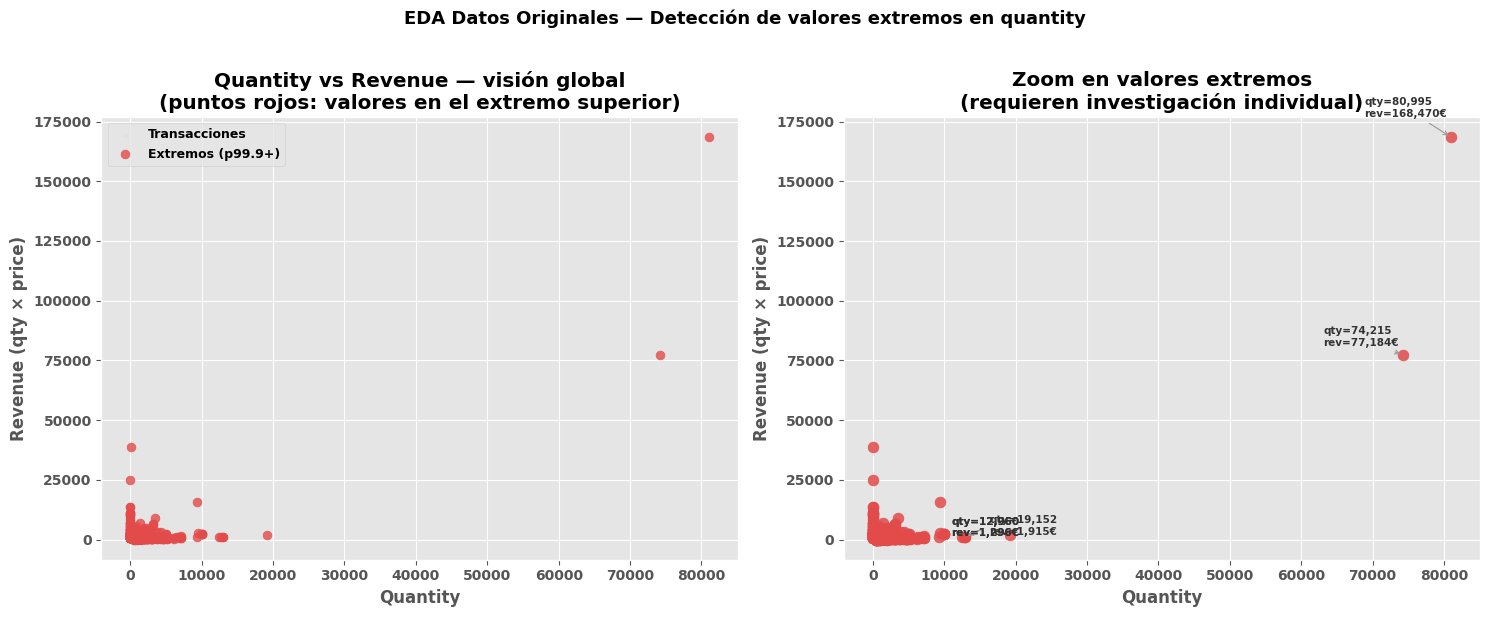

Transacciones normales (≤ p99.9): 1,039,928
Transacciones extremas (> p99.9):  1,743

Top 10 por quantity:
invoice stockcode                        description  quantity           price         revenue     customer_id
 581483     23843        PAPER CRAFT , LITTLE BIRDIE     80995            2.08       168469.60        16446.00
 541431     23166     MEDIUM CERAMIC TOP STORAGE JAR     74215            1.04        77183.60        12346.00
 497946     37410 BLACK AND WHITE PAISLEY FLOWER MUG     19152            0.10         1915.20        13902.00
 501534     21099        SET/6 STRAWBERRY PAPER CUPS     12960            0.10         1296.00        13902.00
 501534     21091        SET/6 WOODLAND PAPER PLATES     12960            0.10         1296.00        13902.00
 501534     21085          SET/6 WOODLAND PAPER CUPS     12744            0.10         1274.40        13902.00
 501534     21092      SET/6 STRAWBERRY PAPER PLATES     12480            0.10         1248.00        13902.00
 5022

In [137]:
# Distribución quantity vs revenue

df_eda = df_original.copy()
df_eda = clean_names(df_eda)
df_eda['revenue'] = df_eda['quantity'] * df_eda['price']

# Solo transacciones con valores positivos para el scatter principal
df_pos = df_eda[(df_eda['quantity'] > 0) & (df_eda['revenue'] > 0)]

# Umbral visual para destacar extremos (percentil 99.9)
q_thresh = df_pos['quantity'].quantile(0.999)
r_thresh = df_pos['revenue'].quantile(0.999)

normales  = df_pos[(df_pos['quantity'] <= q_thresh) & (df_pos['revenue'] <= r_thresh)]
extremos  = df_pos[(df_pos['quantity'] >  q_thresh) | (df_pos['revenue'] >  r_thresh)]

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# --- Scatter izquierdo: visión global ---
axes[0].scatter(normales['quantity'], normales['revenue'],
                alpha=0.05, s=5, color='#B4B2A9', label='Transacciones')
axes[0].scatter(extremos['quantity'], extremos['revenue'],
                alpha=0.8, s=40, color='#E24B4A', label=f'Extremos (p99.9+)')
axes[0].set_xlabel('Quantity')
axes[0].set_ylabel('Revenue (qty × price)')
axes[0].set_title('Quantity vs Revenue — visión global\n(puntos rojos: valores en el extremo superior)')
axes[0].legend(fontsize=9)

# --- Scatter derecho: zoom en extremos ---
axes[1].scatter(extremos['quantity'], extremos['revenue'],
                alpha=0.85, s=60, color='#E24B4A')

# Anotar los más llamativos por quantity
top_qty = extremos.nlargest(5, 'quantity')
for _, row in top_qty.iterrows():
    axes[1].annotate(
        f"qty={int(row['quantity']):,}\nrev={row['revenue']:,.0f}€",
        xy=(row['quantity'], row['revenue']),
        xytext=(row['quantity'] - row['quantity']*0.15, 
                row['revenue'] + row['revenue']*0.05),
        fontsize=7.5, color='#333333',
        arrowprops=dict(arrowstyle='->', color='#999999', lw=0.8)
    )
axes[1].set_xlabel('Quantity')
axes[1].set_ylabel('Revenue (qty × price)')
axes[1].set_title('Zoom en valores extremos\n(requieren investigación individual)')

plt.suptitle('EDA Datos Originales — Detección de valores extremos en quantity',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Tabla resumen de los extremos detectados
print(f"Transacciones normales (≤ p99.9): {len(normales):,}")
print(f"Transacciones extremas (> p99.9):  {len(extremos):,}")
print("\nTop 10 por quantity:")
print(extremos.nlargest(10, 'quantity')[['invoice','stockcode','description',
                                          'quantity','price','revenue','customer_id']]
      .to_string(index=False))

## CALIDAD DE DATOS

### NOMBRES DE VARIABLES

Aplicamos clean_names para estandarizar los nombres de las variables

In [138]:
df = clean_names(df)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype         
---  ------       --------------    -----         
 0   invoice      1067371 non-null  object        
 1   stockcode    1067371 non-null  object        
 2   description  1062989 non-null  object        
 3   quantity     1067371 non-null  int64         
 4   invoicedate  1067371 non-null  datetime64[ns]
 5   price        1067371 non-null  float64       
 6   customer_id  824364 non-null   float64       
 7   country      1067371 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 65.1+ MB


### TIPOS DE VARIABLES

Cambiamos customer_id a Int64

In [139]:
df.invoice.unique()

array([489434, 489435, 489436, ..., 581585, 581586, 581587],
      shape=(53628,), dtype=object)

In [140]:
#Tenemos 19494 devoluciones en nuestro dataset
df['invoice'].astype(str).str.contains('C', na=False).value_counts()

invoice
False    1047877
True       19494
Name: count, dtype: int64

In [141]:
# Cambiamos tipos de variables que correspondan
df = df.astype({'customer_id':'Int64'})
df.dtypes

invoice                object
stockcode              object
description            object
quantity                int64
invoicedate    datetime64[ns]
price                 float64
customer_id             Int64
country                object
dtype: object

### VALORES ÚNICOS

No tenemos constantes en el dataset

In [142]:
# Valores únicos
df.nunique().sort_values()

country           43
quantity        1057
price           2807
stockcode       5305
description     5698
customer_id     5942
invoicedate    47635
invoice        53628
dtype: int64

### VALORES DUPLICADOS

Analizamos los casos y vemos que existen 67242 duplicados que coinciden todas las variables por lo que entendemos que son realmente duplicados y eliminaremos 1 de ellos 

In [143]:
# Duplicados
duplicados = df[df.duplicated(keep=False)]
duplicados

,invoice,stockcode,description,quantity,invoicedate,price,customer_id,country
362,489517,21913,VINTAGE SEASIDE JIGSAW PUZZLES,1,2009-12-01 11:34:00,3.75,16329,United Kingdom
363,489517,21912,VINTAGE SNAKES & LADDERS,1,2009-12-01 11:34:00,3.75,16329,United Kingdom
365,489517,21821,GLITTER STAR GARLAND WITH BELLS,1,2009-12-01 11:34:00,3.75,16329,United Kingdom
367,489517,22319,HAIRCLIPS FORTIES FABRIC ASSORTED,12,2009-12-01 11:34:00,0.65,16329,United Kingdom
368,489517,22130,PARTY CONE CHRISTMAS DECORATION,6,2009-12-01 11:34:00,0.85,16329,United Kingdom
...,...,...,...,...,...,...,...,...
1067136,581538,22068,BLACK PIRATE TREASURE CHEST,1,2011-12-09 11:34:00,0.39,14446,United Kingdom
1067150,581538,23318,BOX OF 6 MINI VINTAGE CRACKERS,1,2011-12-09 11:34:00,2.49,14446,United Kingdom
1067153,581538,22992,REVOLVER WOODEN RULER,1,2011-12-09 11:34:00,1.95,14446,United Kingdom
1067160,581538,22694,WICKER STAR,1,2011-12-09 11:34:00,2.10,14446,United Kingdom


In [144]:
duplicados.loc[duplicados.description == 'BLACK PIRATE TREASURE CHEST']

,invoice,stockcode,description,quantity,invoicedate,price,customer_id,country
106068,499507,22068,BLACK PIRATE TREASURE CHEST,2,2010-02-28 16:01:00,1.65,17209,United Kingdom
106084,499507,22068,BLACK PIRATE TREASURE CHEST,2,2010-02-28 16:01:00,1.65,17209,United Kingdom
230091,511638,22068,BLACK PIRATE TREASURE CHEST,2,2010-06-09 13:08:00,1.65,17346,United Kingdom
230112,511638,22068,BLACK PIRATE TREASURE CHEST,2,2010-06-09 13:08:00,1.65,17346,United Kingdom
281436,516778,22068,BLACK PIRATE TREASURE CHEST,2,2010-07-22 19:56:00,1.65,17602,United Kingdom
281453,516778,22068,BLACK PIRATE TREASURE CHEST,2,2010-07-22 19:56:00,1.65,17602,United Kingdom
447280,532010,22068,BLACK PIRATE TREASURE CHEST,2,2010-11-10 12:42:00,1.65,17321,United Kingdom
447308,532010,22068,BLACK PIRATE TREASURE CHEST,2,2010-11-10 12:42:00,1.65,17321,United Kingdom
503294,536401,22068,BLACK PIRATE TREASURE CHEST,2,2010-12-01 11:21:00,1.65,15862,United Kingdom
504430,536544,22068,BLACK PIRATE TREASURE CHEST,1,2010-12-01 14:32:00,3.36,<NA>,United Kingdom


In [145]:
df.drop_duplicates(inplace = True)
df.duplicated().sum()

np.int64(0)

### VALORES NULOS

In [146]:
df.isna().sum().sort_values(ascending=False)

customer_id    235151
description      4275
stockcode           0
invoice             0
quantity            0
invoicedate         0
price               0
country             0
dtype: int64

#### CUSTOMER_ID

Existe un grupo de mas del 20% de los registros que no tienen customer_id (Entendemos que compraron como invitado en la web). Vamos a identificarlos como '-1' para poder tratarlos después como grupo y aplicarles una acción de motivación para que se registren con un descuento 

In [147]:
df.loc[df['customer_id'].isna()].shape

(235151, 8)

In [148]:
df.loc[(df['invoice'].duplicated())&(df['customer_id'].isna())]

,invoice,stockcode,description,quantity,invoicedate,price,customer_id,country
578,489525,85227,SET/6 3D KIT CARDS FOR KIDS,1,2009-12-01 11:49:00,0.85,<NA>,United Kingdom
1056,489548,22254,FELT TOADSTOOL LARGE,12,2009-12-01 12:32:00,1.25,<NA>,United Kingdom
1057,489548,22273,FELTCRAFT DOLL MOLLY,3,2009-12-01 12:32:00,2.95,<NA>,United Kingdom
1058,489548,22195,LARGE HEART MEASURING SPOONS,1,2009-12-01 12:32:00,1.65,<NA>,United Kingdom
1059,489548,22131,FOOD CONTAINER SET 3 LOVE HEART,2,2009-12-01 12:32:00,1.95,<NA>,United Kingdom
...,...,...,...,...,...,...,...,...
1066997,581498,85099B,JUMBO BAG RED RETROSPOT,5,2011-12-09 10:26:00,4.13,<NA>,United Kingdom
1066998,581498,85099C,JUMBO BAG BAROQUE BLACK WHITE,4,2011-12-09 10:26:00,4.13,<NA>,United Kingdom
1066999,581498,85150,LADIES & GENTLEMEN METAL SIGN,1,2011-12-09 10:26:00,4.96,<NA>,United Kingdom
1067000,581498,85174,S/4 CACTI CANDLES,1,2011-12-09 10:26:00,10.79,<NA>,United Kingdom


In [149]:
# Hay 2628 facturas diferentes con mas de un artículo y no hay customer_id
df.loc[(df['invoice'].duplicated())&(df['customer_id'].isna())].invoice.unique().shape

(2628,)

In [150]:
# El total de facturas que no tienen customer_id es 8752
df.loc[(df['customer_id'].isna())].invoice.unique().shape

(8752,)

In [151]:
# En total hay 235151 registros que no tienen customer_id
df.loc[(df['customer_id'].isna())].shape

(235151, 8)

In [152]:
# customer_id == -1 → comprador invitado (sin registro)
df['customer_id'] = df['customer_id'].fillna(-1).astype('Int64')
df.loc[df['customer_id'].isna()].shape

(0, 8)

In [153]:
df.isna().sum()

invoice           0
stockcode         0
description    4275
quantity          0
invoicedate       0
price             0
customer_id       0
country           0
dtype: int64

#### DESCRIPTION

Vemos que hay 4275 registros que no tienen description pero vamos a hacer una búsqueda por el stockcode que nos permita añadirles la descripción de los que si estén identificados y dejaremos como 'sin_identificar' aquellos que no podamos obtener

In [154]:
df.loc[(df['description'].isna())].head()

,invoice,stockcode,description,quantity,invoicedate,price,customer_id,country
470,489521,21646,NaN,-50,2009-12-01 11:44:00,0.00,-1,United Kingdom
3114,489655,20683,NaN,-44,2009-12-01 17:26:00,0.00,-1,United Kingdom
3161,489659,21350,NaN,230,2009-12-01 17:39:00,0.00,-1,United Kingdom
3731,489781,84292,NaN,17,2009-12-02 11:45:00,0.00,-1,United Kingdom
4296,489806,18010,NaN,-770,2009-12-02 12:42:00,0.00,-1,United Kingdom


In [155]:
df.loc[(df['stockcode']==20683)]

,invoice,stockcode,description,quantity,invoicedate,price,customer_id,country
3114,489655,20683,NaN,-44,2009-12-01 17:26:00,0.00,-1,United Kingdom
24774,491435,20683,RAIN GIRL CHILDS UMBRELLA,1,2009-12-11 10:10:00,3.25,14606,United Kingdom
43854,493252,20683,NaN,1,2009-12-22 13:51:00,0.00,-1,United Kingdom


In [156]:
# Crear diccionario stockcode -> description (solo los que tienen descripción)
desc_map = (
    df.dropna(subset=['description'])
    .drop_duplicates(subset=['stockcode'])
    .set_index('stockcode')['description']
    .to_dict()
)

# Cuántos stockcodes únicos sin descripción pueden ser recuperados
nulos = df[df['description'].isna()]['stockcode'].unique()
recuperables = [s for s in nulos if s in desc_map]
no_recuperables = [s for s in nulos if s not in desc_map]

print(f"Stockcodes sin descripción:   {len(nulos)}")
print(f"Recuperables del propio df:   {len(recuperables)}")
print(f"Sin descripción en ningún lado: {len(no_recuperables)}")

Stockcodes sin descripción:   2451
Recuperables del propio df:   2096
Sin descripción en ningún lado: 355


In [157]:
# Rellenar nulos usando el mapa
df['description'] = df['description'].fillna(df['stockcode'].map(desc_map))

# Verificar cuántos nulos quedan
df['description'].isna().sum()

np.int64(363)

In [158]:
df.loc[(df['description'].isna())]

,invoice,stockcode,description,quantity,invoicedate,price,customer_id,country
470,489521,21646,NaN,-50,2009-12-01 11:44:00,0.00,-1,United Kingdom
16186,490736,35983,NaN,-200,2009-12-07 17:13:00,0.00,-1,United Kingdom
19313,490976,84571,NaN,-120,2009-12-08 16:42:00,0.00,-1,United Kingdom
20975,491066,35949,NaN,-67,2009-12-09 12:17:00,0.00,-1,United Kingdom
22854,491167,17013A,NaN,-45,2009-12-10 11:09:00,0.00,-1,United Kingdom
...,...,...,...,...,...,...,...,...
600756,542582,DCGS0057,NaN,-6,2011-01-28 15:01:00,0.00,-1,United Kingdom
634150,545566,37477D,NaN,-9,2011-03-03 16:14:00,0.00,-1,United Kingdom
804713,561250,DCGS0071,NaN,-2,2011-07-26 11:51:00,0.00,-1,United Kingdom
804715,561255,DCGS0066P,NaN,-3,2011-07-26 11:52:00,0.00,-1,United Kingdom


In [159]:
df['description'] = df['description'].fillna('NO DESCRIPTION').astype('object')
df.loc[(df['description'].isna())].shape

(0, 8)

In [160]:
df.isna().sum()

invoice        0
stockcode      0
description    0
quantity       0
invoicedate    0
price          0
customer_id    0
country        0
dtype: int64

### ATÍPICOS

#### QUANTITY

Hay datos negativos en la variable quantity de los cuales no todos son devoluciones. 

Hay 3393 que no tienen valor en price, no tienen customer_id (ahora -1), todos son de UK y quantity negativo. La conclusión es que son ajustes de inventario de almacén sin valor para segmentación ni forecasting por lo que vamos a eliminar esos registros

In [161]:
# Comprobamos cuantos valores con quantity hay negativos
df.loc[(df['quantity']<0)].quantity.shape

(22496,)

In [162]:
# Generamos df1 para hacer averiguaciones
df1 = df.loc[(df['quantity']<0)]
df1

,invoice,stockcode,description,quantity,invoicedate,price,customer_id,country
178,C489449,22087,PAPER BUNTING WHITE LACE,-12,2009-12-01 10:33:00,2.95,16321,Australia
179,C489449,85206A,CREAM FELT EASTER EGG BASKET,-6,2009-12-01 10:33:00,1.65,16321,Australia
180,C489449,21895,POTTING SHED SOW 'N' GROW SET,-4,2009-12-01 10:33:00,4.25,16321,Australia
181,C489449,21896,POTTING SHED TWINE,-6,2009-12-01 10:33:00,2.10,16321,Australia
182,C489449,22083,PAPER CHAIN KIT RETRO SPOT,-12,2009-12-01 10:33:00,2.95,16321,Australia
...,...,...,...,...,...,...,...,...
1065910,C581490,23144,ZINC T-LIGHT HOLDER STARS SMALL,-11,2011-12-09 09:57:00,0.83,14397,United Kingdom
1067002,C581499,M,Manual,-1,2011-12-09 10:28:00,224.69,15498,United Kingdom
1067176,C581568,21258,VICTORIAN SEWING BOX LARGE,-5,2011-12-09 11:57:00,10.95,15311,United Kingdom
1067177,C581569,84978,HANGING HEART JAR T-LIGHT HOLDER,-1,2011-12-09 11:58:00,1.25,17315,United Kingdom


In [163]:
# Comprobamos que todos registros con quantity negativo NO son devoluciones
df1['invoice'].astype(str).str.contains('C', na=False).value_counts()

invoice
True     19103
False     3393
Name: count, dtype: int64

In [164]:
# Extraemos las devoluciones de df para comprar los datos y concluimos que son las mismas
df['invoice'].astype(str).str.contains('C', na=False).value_counts()

invoice
False    1013932
True       19104
Name: count, dtype: int64

Investigamos los 3393 registros

In [165]:
# Aislar el grupo anómalo: quantity < 1 SIN la 'C'
anomalos = df1[~df1['invoice'].astype(str).str.contains('C', na=False)]
print(anomalos.shape)

(3393, 8)


In [166]:
# Vemos qué tienen en común stockcode, país, customer_id
print(anomalos['stockcode'].value_counts().head()) #Diferentes stockcode. Normal
print(anomalos['country'].value_counts().head()) #Mismo país
print(anomalos['customer_id'].value_counts().head()) #Todos son nulo (-1)

stockcode
22423     11
22719      6
82494L     6
21830      5
46000M     5
Name: count, dtype: int64
country
United Kingdom    3393
Name: count, dtype: int64
customer_id
-1    3393
Name: count, dtype: Int64


In [167]:
# Vemos el precio de los artículos porque sospechamos que podrían ser ajustes de inventario con price = 0.0
anomalos['price'].value_counts()

price
0.00    3393
Name: count, dtype: int64

In [168]:
# Distribución de quantity para entender si son -1, -2 o valores muy grandes
print(anomalos['quantity'].describe())
print(anomalos['quantity'].value_counts().head(20)) #Son cantidades relativamente bajas

count           3393.00
mean            -167.79
std              679.13
min            -9600.00
25%              -82.00
50%              -26.00
75%               -8.00
max               -1.00
Name: quantity, dtype: float64
quantity
-1     211
-2     168
-4     106
-3     100
-5      90
-6      87
-10     72
-9      71
-8      71
-12     66
-30     62
-7      62
-20     58
-15     56
-11     56
-40     48
-14     45
-23     44
-16     43
-21     42
Name: count, dtype: int64


In [169]:
# Eliminamos los 3393 registros
df = df.loc[~((df['quantity'] < 0)&(~df['invoice'].astype(str).str.contains('C', na=False)))]
df.shape

(1029643, 8)

Buscamos los valores mas altos para analizarlos y ver si tiene sentido que se queden o habría que eliminarlos

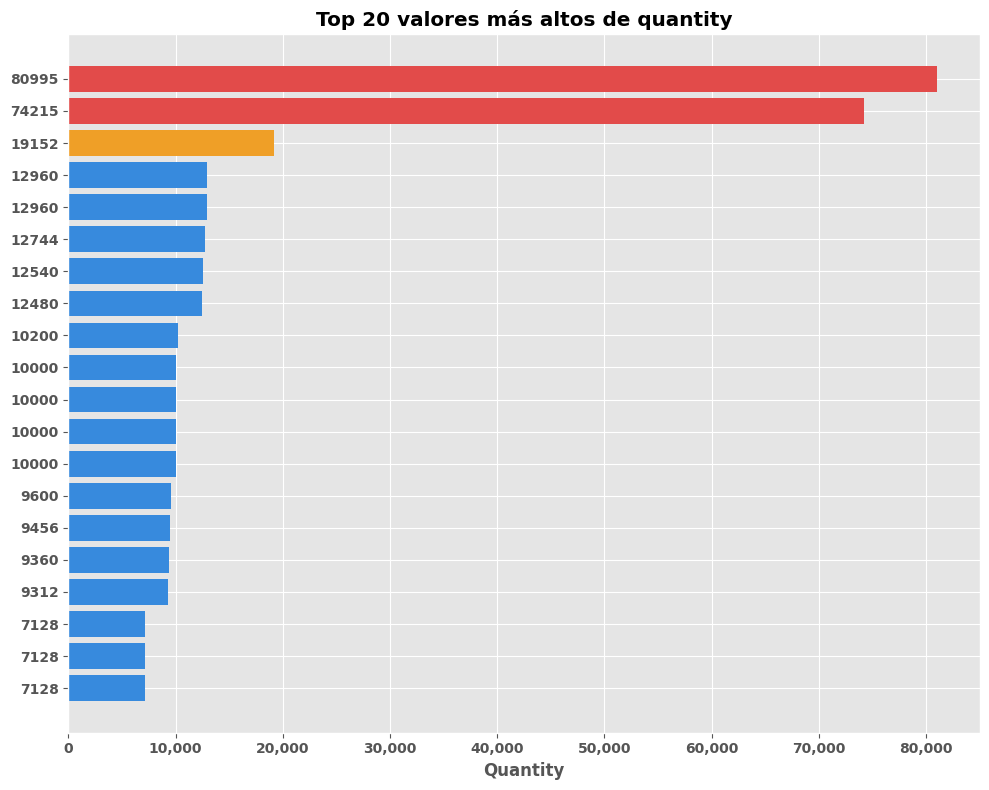

In [170]:
import matplotlib.pyplot as plt

ventas = df[~df['invoice'].astype(str).str.contains('C', na=False) & (df['quantity'] > 0)]
top20 = ventas.nlargest(20, 'quantity')[['quantity', 'invoice', 'customer_id']].reset_index(drop=True)

colors = ['#E24B4A' if v >= 74000 else '#EF9F27' if v >= 19000 else '#378ADD' 
          for v in top20['quantity']]

fig, ax = plt.subplots(figsize=(10, 8))
bars = ax.barh(range(len(top20)), top20['quantity'], color=colors)
ax.set_yticks(range(len(top20)))
ax.set_yticklabels(top20['quantity'].astype(str))
ax.invert_yaxis()
ax.set_xlabel('Quantity')
ax.set_title('Top 20 valores más altos de quantity')
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))

plt.tight_layout()
plt.show()

In [171]:
df.loc[(df.quantity > 10000)|(df.quantity < -10000)]

,invoice,stockcode,description,quantity,invoicedate,price,customer_id,country
90857,497946,37410,BLACK AND WHITE PAISLEY FLOWER MUG,19152,2010-02-15 11:57:00,0.10,13902,Denmark
127166,501534,21099,SET/6 STRAWBERRY PAPER CUPS,12960,2010-03-17 13:09:00,0.10,13902,Denmark
127167,501534,21092,SET/6 STRAWBERRY PAPER PLATES,12480,2010-03-17 13:09:00,0.10,13902,Denmark
127168,501534,21091,SET/6 WOODLAND PAPER PLATES,12960,2010-03-17 13:09:00,0.10,13902,Denmark
127169,501534,21085,SET/6 WOODLAND PAPER CUPS,12744,2010-03-17 13:09:00,0.10,13902,Denmark
192197,507637,84016,FLAG OF ST GEORGE CAR FLAG,10200,2010-05-10 14:55:00,0.00,-1,United Kingdom
587080,541431,23166,MEDIUM CERAMIC TOP STORAGE JAR,74215,2011-01-18 10:01:00,1.04,12346,United Kingdom
587085,C541433,23166,MEDIUM CERAMIC TOP STORAGE JAR,-74215,2011-01-18 10:17:00,1.04,12346,United Kingdom
1027583,578841,84826,ASSTD DESIGN 3D PAPER STICKERS,12540,2011-11-25 15:57:00,0.00,13256,United Kingdom
1065882,581483,23843,"PAPER CRAFT , LITTLE BIRDIE",80995,2011-12-09 09:15:00,2.08,16446,United Kingdom


In [172]:
df.loc[df.customer_id == 13902]

,invoice,stockcode,description,quantity,invoicedate,price,customer_id,country
19479,C490993,37495,FAIRY CAKE BIRTHDAY CANDLE SET,-3,2009-12-08 17:13:00,3.75,13902,Denmark
19480,C490993,21463,MIRRORED DISCO BALL,-1,2009-12-08 17:13:00,5.95,13902,Denmark
32199,491988,21559,STRAWBERRY LUNCHBOX WITH CUTLERY,6,2009-12-15 10:02:00,2.55,13902,Denmark
32200,491988,79323P,PINK CHERRY LIGHTS,12,2009-12-15 10:02:00,6.75,13902,Denmark
32201,491988,79323W,WHITE CHERRY LIGHTS,24,2009-12-15 10:02:00,5.45,13902,Denmark
...,...,...,...,...,...,...,...,...
127170,501534,37379B,BLUE CHERRY BLOSSOM CUP & SAUCER,1110,2010-03-17 13:09:00,0.15,13902,Denmark
127171,501534,37352,BIRD IN TREE MUG,4608,2010-03-17 13:09:00,0.10,13902,Denmark
127172,501534,37351,ORANGE FLOWER MUG,5364,2010-03-17 13:09:00,0.10,13902,Denmark
127173,501534,20688,BEAUTY SPEED EXPRESSO CUPS,420,2010-03-17 13:09:00,0.45,13902,Denmark


In [173]:
# Eliminamos registros que no aportan información y desviarían el efecto del futuro modelo 
df = df[~df['invoice'].astype(str).isin(['581483', 'C581484', '541431', 'C541433', '578841'])]
print(f"Shape tras eliminación: {df.shape}")

Shape tras eliminación: (1029638, 8)


#### DEVOLUCIONES

Sobre las devoluciones, tienen un pedido previo aunque sea del mismo momento por lo que sabemos que son devoluciones reales pero no podemos vincular el pedido con la devolución porque son códigos diferentes. 

Por otro lado, hemos buscado una relacion entre las compras y las devoluciones y observamos que hay clientes que tienen mas devoluciones que pedidos en número de artículos comprados. Puede que sea por compras de periodos anteriores que no están representados en el dataset (Habría que preguntarle a negocio si los datos son lógicos)

Hemos hecho un análisis de los pedidos de grandes volúmenes y concluimos en eliminar varios registros que no aportan información

In [174]:
#Comprobamos que, en los casos en los que no son ajustes de inventario, las devoluciones tienen un pedido previo aunque sea del mismo momento
df.loc[(df['quantity']<0)].sort_values('quantity').head()

,invoice,stockcode,description,quantity,invoicedate,price,customer_id,country
507225,C536757,84347,ROTATING SILVER ANGELS T-LIGHT HLDR,-9360,2010-12-02 14:23:00,0.03,15838,United Kingdom
359669,C524235,21088,SET/6 FRUIT SALAD PAPER CUPS,-7128,2010-09-28 11:02:00,0.08,14277,France
359670,C524235,21096,SET/6 FRUIT SALAD PAPER PLATES,-7008,2010-09-28 11:02:00,0.13,14277,France
359630,C524235,16047,POP ART PEN CASE & PENS,-5184,2010-09-28 11:02:00,0.08,14277,France
359636,C524235,37340,MULTICOLOUR SPRING FLOWER MUG,-4992,2010-09-28 11:02:00,0.10,14277,France


In [175]:
df.loc[(df['customer_id']==12346)].sort_values('quantity', ascending=False).head()

,invoice,stockcode,description,quantity,invoicedate,price,customer_id,country
27994,491725,TEST001,This is a test product.,10,2009-12-14 08:34:00,4.50,12346,United Kingdom
28251,491742,TEST001,This is a test product.,5,2009-12-14 11:00:00,4.50,12346,United Kingdom
28254,491744,TEST001,This is a test product.,5,2009-12-14 11:02:00,4.50,12346,United Kingdom
39398,492718,TEST001,This is a test product.,5,2009-12-18 10:47:00,4.50,12346,United Kingdom
45228,493410,TEST001,This is a test product.,5,2010-01-04 09:24:00,4.50,12346,United Kingdom


In [176]:
df.loc[(df['customer_id']==16446)].sort_values('quantity').head()

,invoice,stockcode,description,quantity,invoicedate,price,customer_id,country
371780,C525275,TEST001,This is a test product.,-2,2010-10-04 16:38:00,4.50,16446,United Kingdom
719815,553573,22980,PANTRY SCRUBBING BRUSH,1,2011-05-18 09:52:00,1.65,16446,United Kingdom
719816,553573,22982,PANTRY PASTRY BRUSH,1,2011-05-18 09:52:00,1.25,16446,United Kingdom


In [177]:
# Separar en 3 grupos limpios para que podamos trabajar con los diferentes grupos
df_ventas     = df[~df['invoice'].astype(str).str.contains('C', na=False) & (df['quantity'] > 0)]
df_devolucion = df[df['invoice'].astype(str).str.contains('C', na=False)]
df_stock      = df[(df['quantity'] < 0) & (~df['invoice'].astype(str).str.contains('C', na=False))]

# Para forecasting: solo df_ventas
# Para segmentación: df_ventas como base + df_devolucion como feature adicional

In [178]:
# Intentamos vincular el número de devolución con el número de pedido para intentar extraer un tiempo de devolución y trabajar con ello pero ambos códigos son independientes y no están vinculados de ninguna forma
# Extraer número de factura original desde la devolución (quitar la 'C')
df_devolucion = df[df['invoice'].astype(str).str.contains('C', na=False)].copy()
df_ventas     = df[~df['invoice'].astype(str).str.contains('C', na=False)].copy()

# La factura original sería el número sin la 'C'
df_devolucion['invoice_origen'] = df_devolucion['invoice'].astype(str).str.replace('C', '')

# Cruzar con la venta original
cruce = df_devolucion.merge(
    df_ventas[['invoice', 'invoicedate', 'stockcode', 'customer_id']],
    left_on='invoice_origen',
    right_on='invoice',
    suffixes=('_devol', '_venta')
)

print(f"Devoluciones que tienen factura origen en el df: {cruce.shape[0]}")
print(f"Devoluciones totales:                            {df_devolucion.shape[0]}")

Devoluciones que tienen factura origen en el df: 0
Devoluciones totales:                            19102


In [179]:
df_devolucion.groupby('customer_id')['quantity'].sum()

customer_id
-1      -3843
12346     -17
12349      -5
12352     -66
12359    -226
         ... 
18280      -2
18282      -5
18284      -1
18286     -16
18287      -2
Name: quantity, Length: 2573, dtype: int64

In [180]:
tasa_devolucion = df_devolucion.groupby('customer_id')['quantity'].sum() / \
                  df_ventas.groupby('customer_id')['quantity'].sum()
tasa_devolucion.sort_values()

customer_id
13776             -3.00
14255             -3.00
15935             -2.49
14832             -2.00
13290             -2.00
              ...      
18278               NaN
18279               NaN
18281               NaN
18283               NaN
18285               NaN
Name: quantity, Length: 5942, dtype: float64

In [181]:
df.loc[df.customer_id==13776]

,invoice,stockcode,description,quantity,invoicedate,price,customer_id,country
71054,C495771,ADJUST,Adjustment by john on 26/01/2010 16,-1,2010-01-26 16:51:00,13.12,13776,United Kingdom
378012,C525876,BANK CHARGES,Bank Charges,-1,2010-10-07 14:12:00,15.00,13776,United Kingdom
378618,C525896,M,Manual,-1,2010-10-07 15:31:00,311.99,13776,United Kingdom
378757,525905,M,Manual,1,2010-10-07 16:07:00,311.99,13776,United Kingdom
378774,C525907,M,Manual,-1,2010-10-07 16:09:00,311.99,13776,United Kingdom
378777,525909,M,Manual,1,2010-10-07 16:11:00,311.99,13776,United Kingdom
378780,C525914,BANK CHARGES,Bank Charges,-1,2010-10-07 16:14:00,45.00,13776,United Kingdom
379210,C525933,M,Manual,-1,2010-10-07 16:59:00,267.05,13776,United Kingdom


### TRATAMIENTO DE FECHAS

Separamos los componentes de las fechas en variables, identificamos días de la semana, trimestres, franjas horarias, etc

In [182]:
df = df.set_index('invoicedate')

def componentes_fecha(dataframe):
    año = dataframe.index.year
    mes = dataframe.index.month
    dia = dataframe.index.day
    hora = dataframe.index.hour

    # Trimestre
    trimestre = dataframe.index.quarter

    # Quincena
    quincena = dia.map(lambda d: 1 if d <= 15 else 2)

    # Franja horaria
    def franja(h):
        if 7 <= h < 13:  return 'mañana'
        elif 13 <= h < 19: return 'tarde'
        elif 19 <= h or h < 1: return 'noche'
        else: return 'madrugada'
    franja_horaria = hora.map(franja)

    # Día de la semana
    dia_semana = dataframe.index.day_name(locale='es_ES')  # lunes, martes...
    num_semana  = dataframe.index.dayofweek                # 0=lunes, 6=domingo

    return pd.DataFrame({
        'invoice_year'    : año,
        'invoice_month'   : mes,
        'invoice_day'     : dia,
        'invoice_hour'    : hora,
        'invoice_quarter' : trimestre,
        'invoice_quincena': quincena,
        'franja_horaria'  : franja_horaria,
        'dia_semana'      : dia_semana,
        'num_dia_semana'  : num_semana
    })

df = pd.concat([df.reset_index(), componentes_fecha(df)], axis=1)
df

,invoicedate,invoice,stockcode,description,quantity,price,customer_id,country,invoice_year,invoice_month,invoice_day,invoice_hour,invoice_quarter,invoice_quincena,franja_horaria,dia_semana,num_dia_semana
0,2009-12-01 07:45:00,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,6.95,13085,United Kingdom,2009,12,1,7,4,1,mañana,Martes,1
1,2009-12-01 07:45:00,489434,79323P,PINK CHERRY LIGHTS,12,6.75,13085,United Kingdom,2009,12,1,7,4,1,mañana,Martes,1
2,2009-12-01 07:45:00,489434,79323W,WHITE CHERRY LIGHTS,12,6.75,13085,United Kingdom,2009,12,1,7,4,1,mañana,Martes,1
3,2009-12-01 07:45:00,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2.10,13085,United Kingdom,2009,12,1,7,4,1,mañana,Martes,1
4,2009-12-01 07:45:00,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,1.25,13085,United Kingdom,2009,12,1,7,4,1,mañana,Martes,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1029633,2011-12-09 12:50:00,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2.10,12680,France,2011,12,9,12,4,1,mañana,Viernes,4
1029634,2011-12-09 12:50:00,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,4.15,12680,France,2011,12,9,12,4,1,mañana,Viernes,4
1029635,2011-12-09 12:50:00,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,4.15,12680,France,2011,12,9,12,4,1,mañana,Viernes,4
1029636,2011-12-09 12:50:00,581587,22138,BAKING SET 9 PIECE RETROSPOT,3,4.95,12680,France,2011,12,9,12,4,1,mañana,Viernes,4


## CREACIÓN DE VARIABLES

### KPIs DE NEGOCIO

**Nivel transacción**

- Revenue: `quantity × price` — Base de todo lo demás. Aplica a forecasting y segmentación.
- Ticket medio: `revenue / n_facturas_únicas` — Valor medio por pedido.
- Unidades por pedido: `quantity / n_facturas_únicas` — Volumen medio por pedido. Útil para forecasting.
- Precio medio por unidad: `revenue / quantity_total` — Detecta cambios de mix de producto.

**Nivel cliente (base RFM):**  es el input directo del clustering. Cada fila es un cliente, cada columna es un KPI. K-Means agrupa clientes por similitud en esas dimensiones.

- Recency: `días desde última compra` — Qué tan reciente es el cliente.
- Numero de compras: `n_facturas_únicas por cliente` — Fidelidad del cliente.
- Monetary: `revenue total por cliente` — Valor económico del cliente.
- CLV simplificado: `ticket_medio × numero_de_compras × vida_estimada` — Potencial de valor futuro.
- Tasa de devolución: `n_devoluciones / n_pedidos` — Comportamiento post-compra.
- Días entre pedidos: `media de días entre facturas consecutivas` — Cadencia de compra del cliente.

**Nivel temporal:**  input del forecasting. revenue_mensual es la serie temporal sobre la que correrá Prophet o ARIMA.

- Revenue mensual / semanal: `sum(revenue)` agrupado por periodo — Serie temporal base para el modelo de forecasting.
- Nuevos clientes por mes: clientes cuya primera compra ocurre ese mes — Mide adquisición, útil para Prophet.
- Pedidos por franja horaria: `count(invoice)` por franja — Patrón intradiario de demanda.

**Nivel producto / país:** análisis descriptivo para contextualizar los segmentos y proponer acciones comerciales.

- Revenue por país: `sum(revenue)` agrupado por country — Peso geográfico del negocio.
- Productos únicos por pedido: `n_stockcodes distintos / factura` — Amplitud del carrito de compra.
- Concentración de producto: `% revenue de los top 10 productos` — Dependencia de SKUs clave.

In [183]:
# ============================================================
# NIVEL TRANSACCIÓN
# ============================================================

df['revenue'] = df['quantity'] * df['price']

revenue_total        = df['revenue'].sum()
ticket_medio         = df.groupby('invoice')['revenue'].sum().mean()
unidades_por_pedido  = df.groupby('invoice')['quantity'].sum().mean()
precio_medio_unidad  = df['revenue'].sum() / df['quantity'].sum()
numero_de_compras    = df.groupby('customer_id')['invoice'].count()


# ============================================================
# TABLA RFM (nivel cliente)
# ============================================================

fecha_referencia = df['invoicedate'].max() - pd.DateOffset(month=6)

rfm = (df[df['invoicedate'] <= fecha_referencia]
       [df['customer_id'] != -1]
       .groupby('customer_id')
       .agg(
           ultima_compra     = ('invoicedate', 'max'),
           primera_compra    = ('invoicedate', 'min'),
           numero_de_compras = ('invoice',     'nunique'),
           monetary          = ('revenue',     'sum')
       ).reset_index())

rfm['recency'] = (fecha_referencia - rfm['ultima_compra']).dt.days
rfm['dias_entre_pedidos'] = (
    (rfm['ultima_compra'] - rfm['primera_compra']).dt.days / (rfm['numero_de_compras'] - 1)).fillna(0)
rfm['clv'] = rfm['monetary'] * rfm['numero_de_compras']


# ============================================================
# TASA DE DEVOLUCIÓN → merge a RFM
# ============================================================

n_pedidos      = df[df['customer_id'] != -1].groupby('customer_id')['invoice'].nunique()
n_devoluciones = (df_devolucion[df_devolucion['customer_id'] != -1]
                  .groupby('customer_id')['invoice'].nunique())

tasa_devolucion = (n_devoluciones / n_pedidos).fillna(0).rename('tasa_devolucion').reset_index()

rfm = rfm.merge(tasa_devolucion, on='customer_id', how='left')
rfm['tasa_devolucion'] = rfm['tasa_devolucion'].fillna(0)


# ============================================================
# ENRIQUECER df CON FEATURES DE CLIENTE
# ============================================================

df = df.merge(
    rfm[['customer_id', 'recency', 'numero_de_compras', 'monetary', 
         'dias_entre_pedidos', 'clv', 'tasa_devolucion']],
    on='customer_id',
    how='left'
)


# ============================================================
# NIVEL TEMPORAL
# ============================================================

revenue_mensual = (df.groupby([df['invoicedate'].dt.year.rename('año'),
                               df['invoicedate'].dt.month.rename('mes')])
                   ['revenue'].sum().reset_index())

nuevos_clientes_mes = (df[df['customer_id'] != -1]
                       .groupby('customer_id')['invoicedate'].min()
                       .dt.to_period('M')
                       .value_counts().sort_index().reset_index())
nuevos_clientes_mes.columns = ['mes', 'nuevos_clientes']

pedidos_por_franja = (df.groupby('franja_horaria')['invoice']
                      .nunique().reset_index()
                      .rename(columns={'invoice': 'n_pedidos'}))


# ============================================================
# NIVEL PRODUCTO / PAÍS
# ============================================================

revenue_por_pais     = (df.groupby('country')['revenue'].sum()
                        .reset_index().sort_values('revenue', ascending=False))

productos_por_pedido = df.groupby('invoice')['stockcode'].nunique().mean()

revenue_por_producto  = df.groupby('stockcode')['revenue'].sum().sort_values(ascending=False)
concentracion_top10   = revenue_por_producto.head(10).sum() / revenue_total * 100

In [184]:
print("=== NIVEL TRANSACCIÓN ===")
print(f"Revenue total:           {revenue_total:,.2f} £")
print(f"Ticket medio:            {ticket_medio:,.2f} £")
print(f"Unidades por pedido:     {unidades_por_pedido:,.1f}")
print(f"Precio medio por unidad: {precio_medio_unidad:,.2f} £")

=== NIVEL TRANSACCIÓN ===
Revenue total:           18,855,533.70 £
Ticket medio:            375.38 £
Unidades por pedido:     218.3
Precio medio por unidad: 1.72 £


In [185]:
print("\n=== NIVEL CLIENTE (RFM) ===")
print(rfm[['customer_id','recency','numero_de_compras','monetary','dias_entre_pedidos','clv']].describe().round(2))



=== NIVEL CLIENTE (RFM) ===
          customer_id         recency  numero_de_compras        monetary  \
count         5032.00         5032.00            5032.00         5032.00   
mean         15341.69          171.83               6.40         2244.92   
std           1703.75          147.08              12.64        10217.78   
min          12346.00            0.00               1.00       -25111.09   
25%          13878.75           36.00               1.00          297.35   
50%          15338.50          148.00               3.00          713.64   
75%          16821.25          250.00               7.00         1840.14   
max          18287.00          555.00             341.00       389425.54   

       dias_entre_pedidos             clv  
count             5032.00         5032.00  
mean                49.26        94798.93  
std                 64.39      1396621.17  
min                  0.00       -48973.60  
25%                  0.00          394.04  
50%                 30

In [186]:
print("\n=== TASA DE DEVOLUCIÓN ===")
print(tasa_devolucion['tasa_devolucion'].describe().round(3))


=== TASA DE DEVOLUCIÓN ===
count           5941.00
mean               0.13
std                0.19
min                0.00
25%                0.00
50%                0.00
75%                0.22
max                1.00
Name: tasa_devolucion, dtype: float64


In [187]:
print("\n=== NIVEL TEMPORAL ===")
print(revenue_mensual)
print("\nNuevos clientes por mes:")
print(nuevos_clientes_mes)
print("\nPedidos por franja:")
print(pedidos_por_franja)



=== NIVEL TEMPORAL ===
     año  mes         revenue
0   2009   12       796648.50
1   2010    1       622479.50
2   2010    2       531265.37
3   2010    3       763247.24
4   2010    4       587926.69
5   2010    5       613270.72
6   2010    6       677073.87
7   2010    7       573333.69
8   2010    8       654774.39
9   2010    9       851105.96
10  2010   10      1041685.61
11  2010   11      1416697.20
12  2010   12       746723.61
13  2011    1       558448.56
14  2011    2       497026.41
15  2011    3       682013.98
16  2011    4       492367.84
17  2011    5       722094.10
18  2011    6       689977.23
19  2011    7       680156.99
20  2011    8       681386.46
21  2011    9      1017596.68
22  2011   10      1069368.23
23  2011   11      1456145.80
24  2011   12       432719.06

Nuevos clientes por mes:
        mes  nuevos_clientes
0   2009-12             1045
1   2010-01              394
2   2010-02              363
3   2010-03              436
4   2010-04              

In [188]:
print("\n=== NIVEL PRODUCTO / PAÍS ===")
print(f"Productos únicos por pedido: {productos_por_pedido:.1f}")
print(f"Concentración top 10 SKUs:   {concentracion_top10:.1f}%")
print("\nRevenue por país:")
print(revenue_por_pais)


=== NIVEL PRODUCTO / PAÍS ===
Productos únicos por pedido: 20.3
Concentración top 10 SKUs:   9.1%

Revenue por país:
                 country         revenue
40        United Kingdom     15986060.34
11                  EIRE       609953.78
26           Netherlands       548330.70
15               Germany       411959.16
14                France       321733.39
0              Australia       166444.42
36           Switzerland        99403.06
34                 Spain        91013.44
35                Sweden        87775.52
10               Denmark        64459.59
3                Belgium        63208.89
30              Portugal        51403.68
7        Channel Islands        41080.18
21                 Japan        39662.10
28                Norway        35455.91
20                 Italy        30254.10
13               Finland        29514.45
8                 Cyprus        24032.56
1                Austria        23177.60
16                Greece        18995.49
17             Hong K

In [189]:
# Extraemos RFM para visualizarla
rfm

,customer_id,ultima_compra,primera_compra,numero_de_compras,monetary,recency,dias_entre_pedidos,clv,tasa_devolucion
0,12346,2010-10-04 16:33:00,2009-12-14 08:34:00,15,-51.74,247,21.00,-776.10,0.27
1,12347,2011-04-07 10:43:00,2010-10-31 14:20:00,4,2434.96,63,52.33,9739.84,0.00
2,12348,2011-04-05 10:47:00,2010-09-27 14:59:00,4,1709.40,65,63.00,6837.60,0.00
3,12349,2010-10-28 08:23:00,2009-12-04 12:49:00,4,2646.99,224,109.00,10587.96,0.20
4,12350,2011-02-02 16:01:00,2011-02-02 16:01:00,1,334.40,126,0.00,334.40,0.00
...,...,...,...,...,...,...,...,...,...
5027,18283,2011-05-23 11:33:00,2010-02-19 17:16:00,11,1134.89,17,45.70,12483.79,0.00
5028,18284,2010-10-06 12:31:00,2010-10-04 11:33:00,2,436.68,246,2.00,873.36,0.50
5029,18285,2010-02-17 10:24:00,2010-02-17 10:24:00,1,427.00,477,0.00,427.00,0.00
5030,18286,2010-08-20 11:57:00,2009-12-16 10:45:00,3,1188.43,293,123.50,3565.29,0.33


In [190]:
pd.concat([df,rfm], axis=1)

,invoicedate,invoice,stockcode,description,quantity,price,customer_id,country,invoice_year,invoice_month,invoice_day,invoice_hour,invoice_quarter,invoice_quincena,franja_horaria,dia_semana,num_dia_semana,revenue,recency,numero_de_compras,monetary,dias_entre_pedidos,clv,tasa_devolucion,customer_id,ultima_compra,primera_compra,numero_de_compras,monetary,recency,dias_entre_pedidos,clv,tasa_devolucion
0,2009-12-01 07:45:00,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,6.95,13085,United Kingdom,2009,12,1,7,4,1,mañana,Martes,1,83.40,41.00,9.00,1321.48,64.12,11893.32,0.20,12346,2010-10-04 16:33:00,2009-12-14 08:34:00,15.00,-51.74,247.00,21.00,-776.10,0.27
1,2009-12-01 07:45:00,489434,79323P,PINK CHERRY LIGHTS,12,6.75,13085,United Kingdom,2009,12,1,7,4,1,mañana,Martes,1,81.00,41.00,9.00,1321.48,64.12,11893.32,0.20,12347,2011-04-07 10:43:00,2010-10-31 14:20:00,4.00,2434.96,63.00,52.33,9739.84,0.00
2,2009-12-01 07:45:00,489434,79323W,WHITE CHERRY LIGHTS,12,6.75,13085,United Kingdom,2009,12,1,7,4,1,mañana,Martes,1,81.00,41.00,9.00,1321.48,64.12,11893.32,0.20,12348,2011-04-05 10:47:00,2010-09-27 14:59:00,4.00,1709.40,65.00,63.00,6837.60,0.00
3,2009-12-01 07:45:00,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2.10,13085,United Kingdom,2009,12,1,7,4,1,mañana,Martes,1,100.80,41.00,9.00,1321.48,64.12,11893.32,0.20,12349,2010-10-28 08:23:00,2009-12-04 12:49:00,4.00,2646.99,224.00,109.00,10587.96,0.20
4,2009-12-01 07:45:00,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,1.25,13085,United Kingdom,2009,12,1,7,4,1,mañana,Martes,1,30.00,41.00,9.00,1321.48,64.12,11893.32,0.20,12350,2011-02-02 16:01:00,2011-02-02 16:01:00,1.00,334.40,126.00,0.00,334.40,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1029633,2011-12-09 12:50:00,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2.10,12680,France,2011,12,9,12,4,1,mañana,Viernes,4,12.60,NaN,NaN,NaN,NaN,NaN,NaN,<NA>,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN
1029634,2011-12-09 12:50:00,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,4.15,12680,France,2011,12,9,12,4,1,mañana,Viernes,4,16.60,NaN,NaN,NaN,NaN,NaN,NaN,<NA>,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN
1029635,2011-12-09 12:50:00,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,4.15,12680,France,2011,12,9,12,4,1,mañana,Viernes,4,16.60,NaN,NaN,NaN,NaN,NaN,NaN,<NA>,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN
1029636,2011-12-09 12:50:00,581587,22138,BAKING SET 9 PIECE RETROSPOT,3,4.95,12680,France,2011,12,9,12,4,1,mañana,Viernes,4,14.85,NaN,NaN,NaN,NaN,NaN,NaN,<NA>,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN


### TARGET

Generamos la target partiendo df en dos ciclos temporales (18 y 6 meses) e identificamos los customer_id que están en ambos (1) y los que no aparecen (0)

Nota: La target esta casi al 50/50 por lo que no necesitaremos realizar balanceo de clases

Vamos a generar un dataset fecha_corte_18 y otro fecha_corte_6 donde incluiremos la columna target y después construiremos target_df haciendo un merge para marcar los customer_id que estaban en los primeros 18 y meses y volvieron a estar en los últimos 6 porque volvieron a comprar. Estos customer_id representan nuestra target

In [191]:
fecha_corte_18 = df['invoicedate'].max() - pd.DateOffset(months=6)
clientes_18 = (df[df['invoicedate'] <= fecha_corte_18]
                       .groupby('customer_id')['invoice']
                       .nunique()
                       .reset_index())
clientes_18

,customer_id,invoice
0,-1,4168
1,12346,15
2,12347,4
3,12348,4
4,12349,4
...,...,...
5028,18283,11
5029,18284,2
5030,18285,1
5031,18286,3


In [192]:
fecha_corte_6 = df['invoicedate'].max() - pd.DateOffset(months=6)
clientes_6 = (df[df['invoicedate'] >= fecha_corte_6]
                       .groupby('customer_id')['invoice']
                       .nunique()
                       .reset_index())
clientes_6['target'] = 1
clientes_6

,customer_id,invoice,target
0,-1,1191,1
1,12347,4,1
2,12348,1,1
3,12349,1,1
4,12352,3,1
...,...,...,...
3513,18278,1,1
3514,18281,1,1
3515,18282,3,1
3516,18283,11,1


In [193]:
target_df = pd.merge(clientes_18,clientes_6[['customer_id','target']],how='left',on=['customer_id'])
target_df['target'] = target_df['target'].fillna(0).astype('Int64')
target_df.target.value_counts(dropna=False)

target
1    2609
0    2424
Name: count, dtype: Int64

In [194]:
target_df

,customer_id,invoice,target
0,-1,4168,1
1,12346,15,0
2,12347,4,1
3,12348,4,1
4,12349,4,1
...,...,...,...
5028,18283,11,1
5029,18284,2,0
5030,18285,1,0
5031,18286,3,0


A continuación unimos la tabla rfm con target_df para terminar de tener nuestra tabla completa. Hacemos un análisis exploratorio de ella y nos damos cuenta que hay valores negativos que no deberían estar y concluímos que esos valores vienen de clientes que compraron antes del inicio del dataset, devolvieron dentro del periodo, y el modelo solo ve la devolución sin ver la compra original, por lo que vamos a eliminar los customer_id que tengan esos valores negativos de RFM y quedarnos solamente con los valores de monetary que sean positivos y además, eliminaremos los customer_id del df principal para que no generen ruido al hacer las visualizaciones

In [195]:
rfm = pd.merge(rfm, target_df, how='left', on='customer_id')
rfm

,customer_id,ultima_compra,primera_compra,numero_de_compras,monetary,recency,dias_entre_pedidos,clv,tasa_devolucion,invoice,target
0,12346,2010-10-04 16:33:00,2009-12-14 08:34:00,15,-51.74,247,21.00,-776.10,0.27,15,0
1,12347,2011-04-07 10:43:00,2010-10-31 14:20:00,4,2434.96,63,52.33,9739.84,0.00,4,1
2,12348,2011-04-05 10:47:00,2010-09-27 14:59:00,4,1709.40,65,63.00,6837.60,0.00,4,1
3,12349,2010-10-28 08:23:00,2009-12-04 12:49:00,4,2646.99,224,109.00,10587.96,0.20,4,1
4,12350,2011-02-02 16:01:00,2011-02-02 16:01:00,1,334.40,126,0.00,334.40,0.00,1,0
...,...,...,...,...,...,...,...,...,...,...,...
5027,18283,2011-05-23 11:33:00,2010-02-19 17:16:00,11,1134.89,17,45.70,12483.79,0.00,11,1
5028,18284,2010-10-06 12:31:00,2010-10-04 11:33:00,2,436.68,246,2.00,873.36,0.50,2,0
5029,18285,2010-02-17 10:24:00,2010-02-17 10:24:00,1,427.00,477,0.00,427.00,0.00,1,0
5030,18286,2010-08-20 11:57:00,2009-12-16 10:45:00,3,1188.43,293,123.50,3565.29,0.33,3,0


In [196]:
rfm.isna().sum()

customer_id           0
ultima_compra         0
primera_compra        0
numero_de_compras     0
monetary              0
recency               0
dias_entre_pedidos    0
clv                   0
tasa_devolucion       0
invoice               0
target                0
dtype: int64

In [197]:
rfm.loc[rfm.monetary<0].target.value_counts()

target
0    81
1     4
Name: count, dtype: Int64

In [198]:
# customer_ids con monetary negativo
ids_negativos = rfm[rfm['monetary'] < 0]['customer_id'].tolist()

# Eliminar del df principal
df = df[~df['customer_id'].isin(ids_negativos)]

# Eliminar del rfm
rfm = rfm.loc[rfm['monetary'] >= 0]

In [199]:
df.shape

(1029001, 24)

In [200]:
rfm.shape

(4947, 11)

## EDA - RFM

El dataset contiene 1 millón de transacciones. Para construir el modelo necesitamos resumir el comportamiento de cada cliente en un único registro. Para ello calculamos 5 KPIs que describen su historial completo: cuánto lleva sin comprar, cuántas veces ha comprado, cuánto ha gastado, con qué cadencia compra y cuánto devuelve.
Para construir la variable objetivo dividimos los 24 meses en dos ventanas: entrenamos con los primeros 18 meses de comportamiento y definimos la target como si el cliente volvió a comprar en los últimos 6 meses. Esto nos permite simular una predicción real — usamos el pasado para predecir el futuro.

El resultado es una tabla de 4,947 clientes, cada uno descrito por sus 5 KPIs y etiquetado con 1 si volvió a comprar y 0 si no. Esa tabla es el input del modelo.

Lo primero que observamos es que la mayoría de clientes compran poco y gastan poco — las distribuciones están fuertemente sesgadas a la derecha, con una minoría de clientes de alto valor que distorsionan la escala. Esto es típico en retail: el 20% de clientes genera el 80% del revenue.

Cuando separamos por target, se ve más claro: los clientes que vuelven a comprar llevan de media 105 días sin comprar, mientras que los que no vuelven llevan 237 días. 
- La recency es el predictor más potente. 
- Los clientes que vuelven tienen el triple de compras y cuatro veces más gasto que los que no vuelven — son clientes más activos y más valiosos en todos los sentidos.
- La correlación entre monetary y CLV es de 0.87 — prácticamente la misma información — por lo que eliminamos CLV para evitar redundancia en el modelo.

### GRÁFICOS 

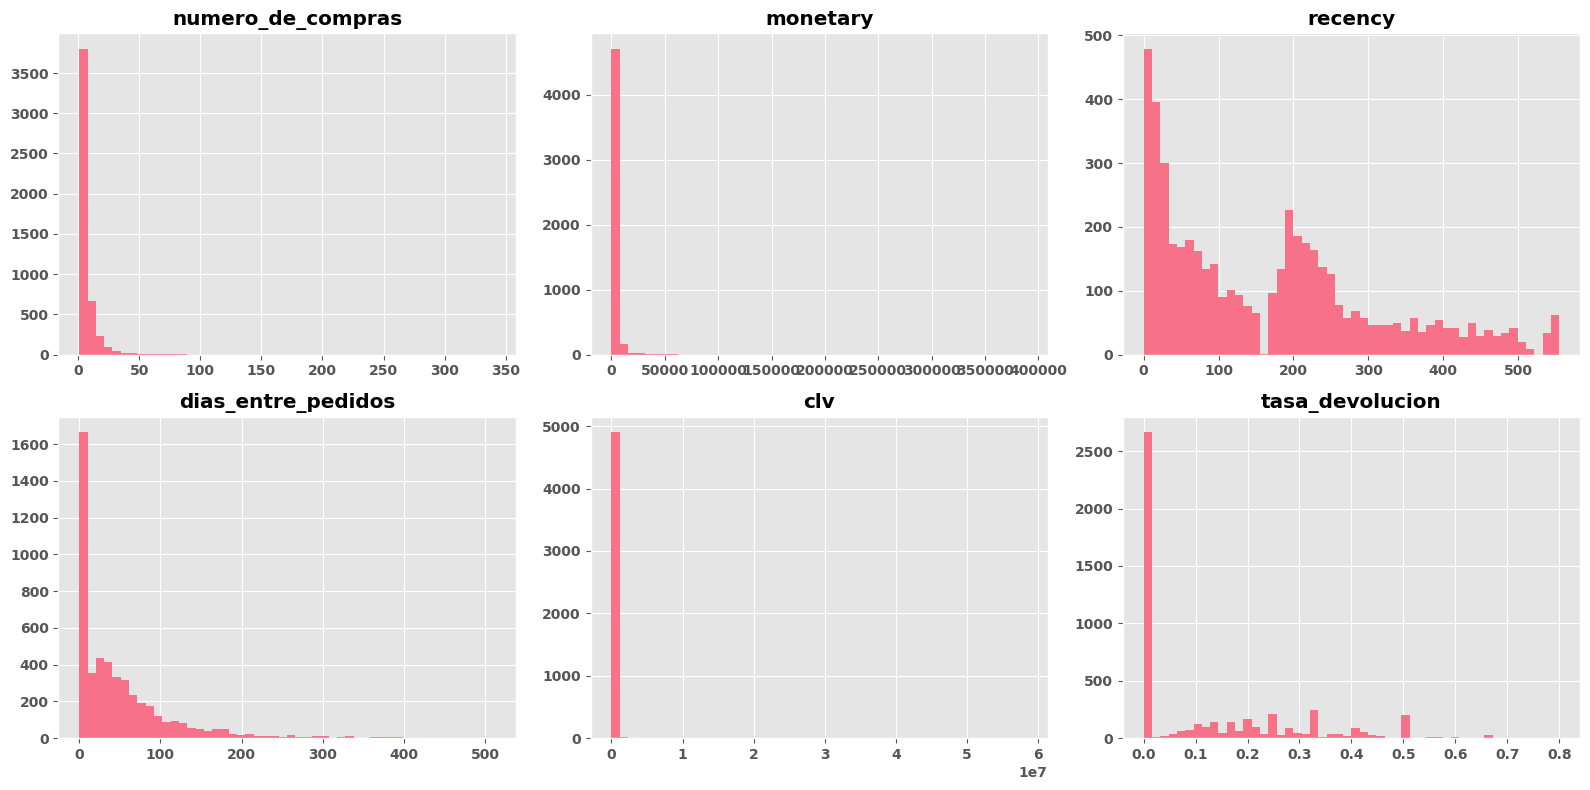

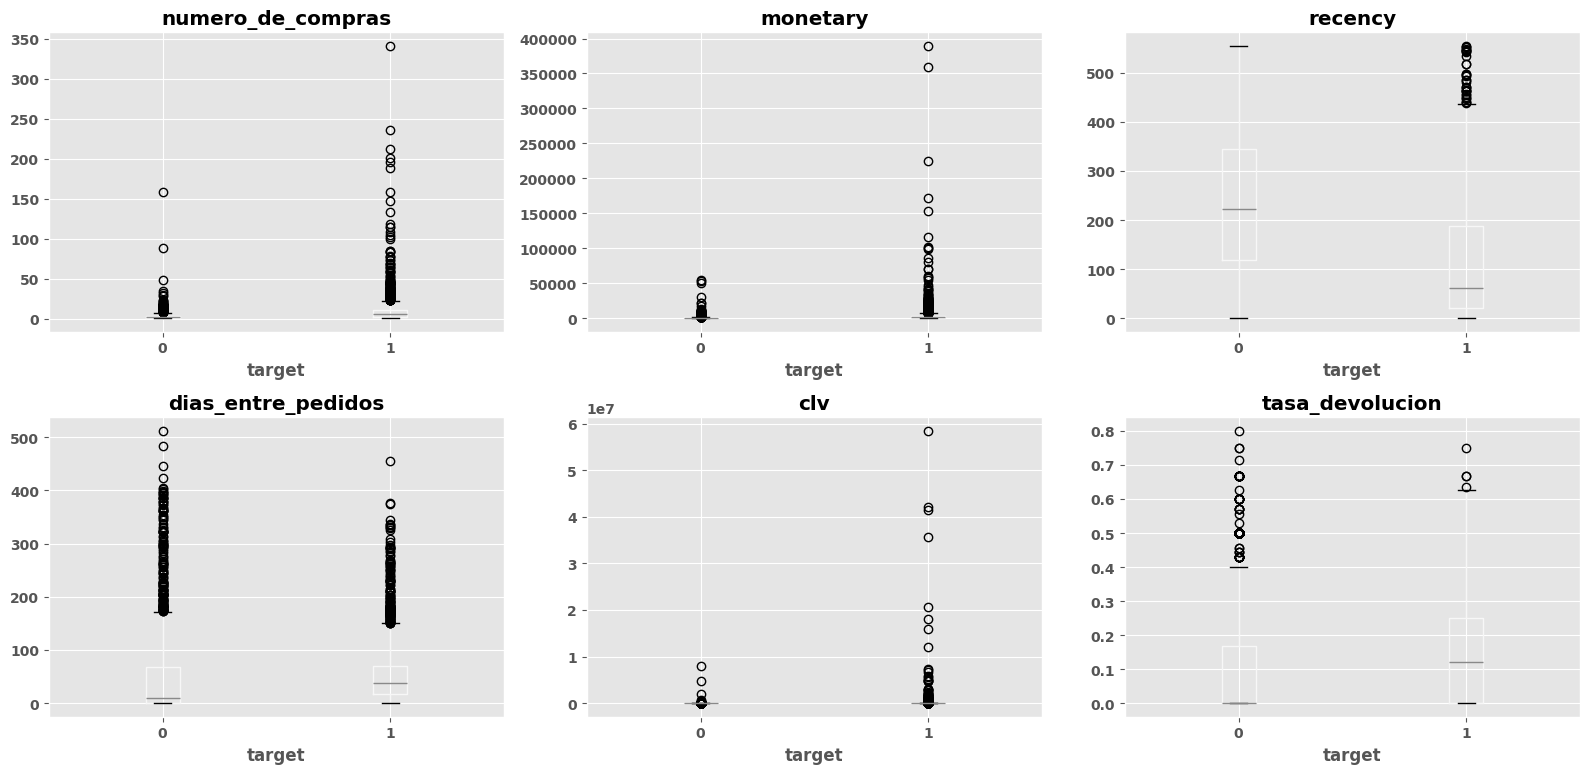

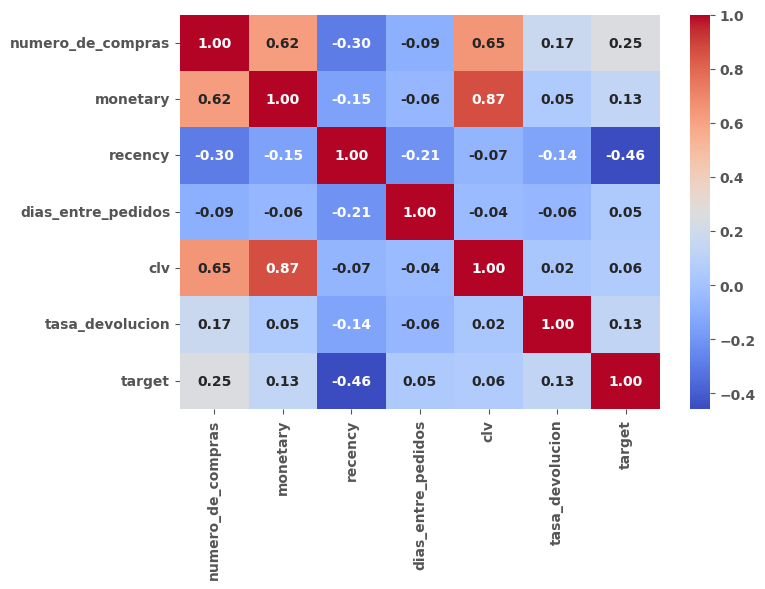

        numero_de_compras        monetary         recency  dias_entre_pedidos  \
target                                                                          
0                    3.06          847.48          237.71               46.73   
1                    9.54         3611.55          105.20               52.82   

                   clv  tasa_devolucion  
target                                   
0             11167.42             0.10  
1            173235.84             0.14  


In [201]:
features = ['numero_de_compras', 'monetary', 'recency', 
            'dias_entre_pedidos', 'clv', 'tasa_devolucion']

# ============================================================
# 1. DISTRIBUCIONES
# ============================================================

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(features):
    rfm[col].hist(bins=50, ax=axes[i])
    axes[i].set_title(col)
    axes[i].set_xlabel('')

plt.tight_layout()
plt.show()


# ============================================================
# 2. BOXPLOTS POR TARGET
# ============================================================

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(features):
    rfm.boxplot(column=col, by='target', ax=axes[i])
    axes[i].set_title(col)
    axes[i].set_xlabel('target')

plt.suptitle('')
plt.tight_layout()
plt.show()


# ============================================================
# 3. CORRELACIÓN
# ============================================================

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(rfm[features + ['target']].corr(), 
            annot=True, fmt='.2f', cmap='coolwarm', ax=ax)
plt.tight_layout()
plt.show()


# ============================================================
# 4. ESTADÍSTICOS POR TARGET
# ============================================================

print(rfm.groupby('target')[features].mean().round(2))

In [202]:
# Eliminamos CLV
rfm = rfm.drop(columns='clv')
rfm

,customer_id,ultima_compra,primera_compra,numero_de_compras,monetary,recency,dias_entre_pedidos,tasa_devolucion,invoice,target
1,12347,2011-04-07 10:43:00,2010-10-31 14:20:00,4,2434.96,63,52.33,0.00,4,1
2,12348,2011-04-05 10:47:00,2010-09-27 14:59:00,4,1709.40,65,63.00,0.00,4,1
3,12349,2010-10-28 08:23:00,2009-12-04 12:49:00,4,2646.99,224,109.00,0.20,4,1
4,12350,2011-02-02 16:01:00,2011-02-02 16:01:00,1,334.40,126,0.00,0.00,1,0
5,12351,2010-11-29 15:23:00,2010-11-29 15:23:00,1,300.93,191,0.00,0.00,1,0
...,...,...,...,...,...,...,...,...,...,...
5027,18283,2011-05-23 11:33:00,2010-02-19 17:16:00,11,1134.89,17,45.70,0.00,11,1
5028,18284,2010-10-06 12:31:00,2010-10-04 11:33:00,2,436.68,246,2.00,0.50,2,0
5029,18285,2010-02-17 10:24:00,2010-02-17 10:24:00,1,427.00,477,0.00,0.00,1,0
5030,18286,2010-08-20 11:57:00,2009-12-16 10:45:00,3,1188.43,293,123.50,0.33,3,0


### EVOLUCIÓN TEMPORAL DEL REVENUE

El negocio vende artículos de regalo. Antes de construir ningún modelo, merece la pena preguntarse si la demanda es uniforme a lo largo del año o si hay patrones estacionales marcados. La serie temporal del revenue mensual responde esa pregunta de forma inmediata: el patrón de Q4 (octubre-diciembre) domina con claridad en los dos años disponibles, lo que justifica haber incluido invoice_quarter como variable del modelo. Un cliente que compra en Q4 tiene un perfil de comportamiento distinto al que compra en verano — y el modelo necesita capturar esa señal.

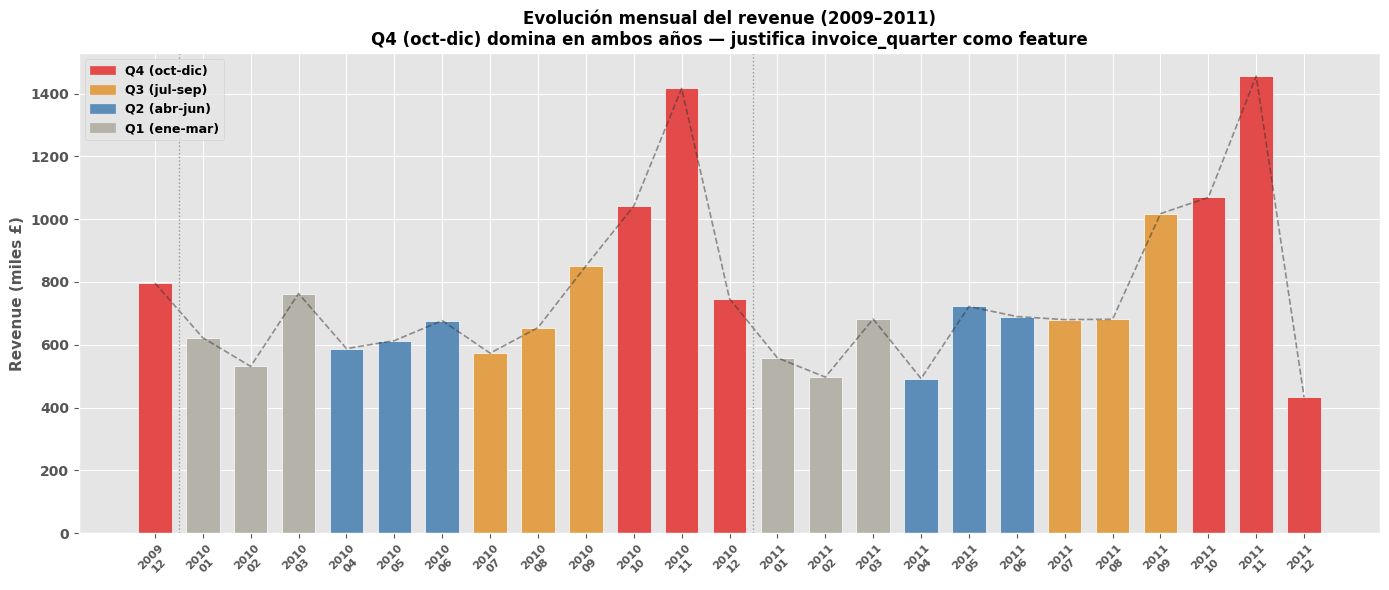

trimestre
Q4    £994,284
Q3    £743,059
Q2    £630,452
Q1    £609,080
Name: revenue, dtype: object


In [203]:
# Evolución temporal del revenue

# revenue_mensual ya está calculado en el notebook
# Crear columna de fecha para el eje X
revenue_mensual['fecha'] = pd.to_datetime(
    revenue_mensual['año'].astype(str) + '-' + 
    revenue_mensual['mes'].astype(str).str.zfill(2)
)

# Colorear barras por trimestre
def color_trimestre(mes):
    if mes in [10, 11, 12]: return '#E24B4A'   # Q4 — destacado
    elif mes in [7, 8, 9]:  return '#E2A04A'   # Q3
    elif mes in [4, 5, 6]:  return '#5B8DB8'   # Q2
    else:                   return '#B4B2A9'   # Q1

revenue_mensual['color'] = revenue_mensual['mes'].map(color_trimestre)

fig, ax = plt.subplots(figsize=(14, 6))

bars = ax.bar(range(len(revenue_mensual)), 
              revenue_mensual['revenue'] / 1000,
              color=revenue_mensual['color'], 
              width=0.7, edgecolor='white', linewidth=0.5)

# Línea de tendencia
ax.plot(range(len(revenue_mensual)), 
        revenue_mensual['revenue'] / 1000,
        color='#333333', linewidth=1.2, alpha=0.5, linestyle='--')

# Etiquetas eje X
etiquetas = [f"{row['año']}\n{row['mes']:02d}" 
             for _, row in revenue_mensual.iterrows()]
ax.set_xticks(range(len(revenue_mensual)))
ax.set_xticklabels(etiquetas, fontsize=8, rotation=45)

# Separador visual entre años
for i, (_, row) in enumerate(revenue_mensual.iterrows()):
    if row['mes'] == 1:
        ax.axvline(x=i - 0.5, color='#999999', linestyle=':', linewidth=1)

ax.set_ylabel('Revenue (miles £)', fontsize=11)
ax.set_title('Evolución mensual del revenue (2009–2011)\n'
             'Q4 (oct-dic) domina en ambos años — justifica invoice_quarter como feature',
             fontsize=12)

# Leyenda de colores por trimestre
from matplotlib.patches import Patch
leyenda = [
    Patch(color='#E24B4A', label='Q4 (oct-dic)'),
    Patch(color='#E2A04A', label='Q3 (jul-sep)'),
    Patch(color='#5B8DB8', label='Q2 (abr-jun)'),
    Patch(color='#B4B2A9', label='Q1 (ene-mar)'),
]
ax.legend(handles=leyenda, fontsize=9, loc='upper left')

plt.tight_layout()
plt.show()

# Resumen por trimestre
revenue_mensual['trimestre'] = revenue_mensual['mes'].map(
    {1:'Q1',2:'Q1',3:'Q1',4:'Q2',5:'Q2',6:'Q2',
     7:'Q3',8:'Q3',9:'Q3',10:'Q4',11:'Q4',12:'Q4'})
print(revenue_mensual.groupby('trimestre')['revenue'].mean()
      .sort_values(ascending=False)
      .apply(lambda x: f"£{x:,.0f}"))

### TOP 10 PRODUCTOS POR REVENUE Y VOLUMEN

Sabemos que los 10 productos más vendidos concentran el 9,1% del revenue total, lo que indica una base de catálogo amplia y poco concentrada. Pero ese KPI por sí solo no revela si los productos más vendidos en unidades son los mismos que más revenue generan. Si los dos rankings no coinciden, hay productos de alto volumen con precio unitario bajo. Habría que ver con negocio sobre si interesa potenciar los de mayor margen. El doble gráfico muestra esa comparación de forma directa.

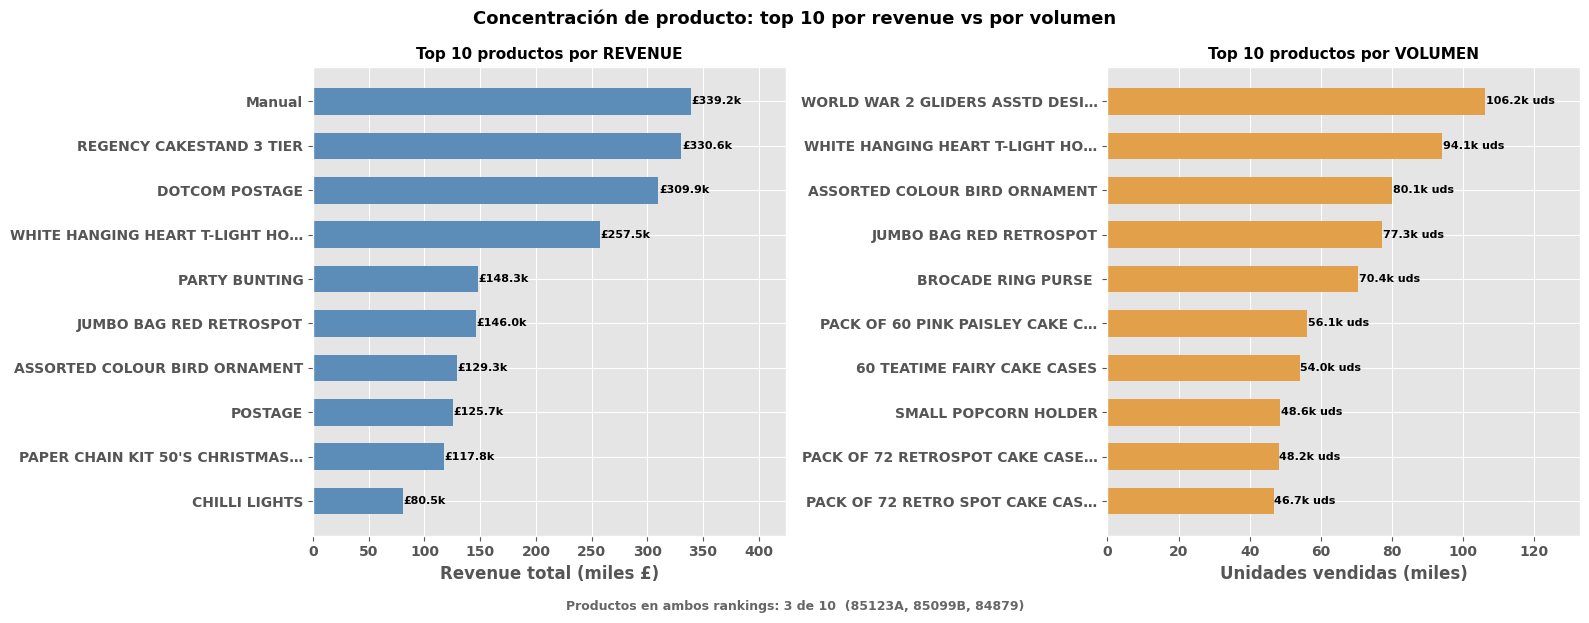

Productos en TOP revenue que también están en TOP volumen: 3
Productos exclusivos de revenue:  7
Productos exclusivos de volumen:  6


In [204]:
# Top 10 productos

# Usar df_ventas (solo ventas, sin devoluciones)
df_ventas['revenue'] = df_ventas['quantity'] * df_ventas['price']

top_revenue = (df_ventas.groupby(['stockcode', 'description'])['revenue']
               .sum()
               .reset_index()
               .sort_values('revenue', ascending=False)
               .head(10))

top_volumen = (df_ventas.groupby(['stockcode', 'description'])['quantity']
               .sum()
               .reset_index()
               .sort_values('quantity', ascending=False)
               .head(10))

# Etiquetas cortas para el gráfico
def etiqueta(desc, max_len=30):
    return desc[:max_len] + '…' if len(desc) > max_len else desc

top_revenue['label'] = top_revenue['description'].apply(etiqueta)
top_volumen['label'] = top_volumen['description'].apply(etiqueta)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Top 10 por revenue ---
axes[0].barh(top_revenue['label'][::-1], 
             top_revenue['revenue'][::-1] / 1000,
             color='#5B8DB8', height=0.6)
for i, (val, label) in enumerate(zip(top_revenue['revenue'][::-1] / 1000, 
                                      top_revenue['label'][::-1])):
    axes[0].text(val + 0.5, i, f'£{val:,.1f}k', va='center', fontsize=8)
axes[0].set_xlabel('Revenue total (miles £)')
axes[0].set_title('Top 10 productos por REVENUE', fontsize=11, fontweight='bold')
axes[0].set_xlim(0, top_revenue['revenue'].max() / 1000 * 1.25)

# --- Top 10 por volumen ---
axes[1].barh(top_volumen['label'][::-1],
             top_volumen['quantity'][::-1] / 1000,
             color='#E2A04A', height=0.6)
for i, (val, label) in enumerate(zip(top_volumen['quantity'][::-1] / 1000,
                                      top_volumen['label'][::-1])):
    axes[1].text(val + 0.2, i, f'{val:,.1f}k uds', va='center', fontsize=8)
axes[1].set_xlabel('Unidades vendidas (miles)')
axes[1].set_title('Top 10 productos por VOLUMEN', fontsize=11, fontweight='bold')
axes[1].set_xlim(0, top_volumen['quantity'].max() / 1000 * 1.25)

# Marcar productos que aparecen en ambos rankings
comunes = set(top_revenue['stockcode']) & set(top_volumen['stockcode'])
if comunes:
    fig.text(0.5, -0.02, 
             f'Productos en ambos rankings: {len(comunes)} de 10  '
             f'({", ".join(str(c) for c in comunes)})',
             ha='center', fontsize=9, color='#666666')

plt.suptitle('Concentración de producto: top 10 por revenue vs por volumen',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"Productos en TOP revenue que también están en TOP volumen: {len(comunes)}")
print(f"Productos exclusivos de revenue:  {len(set(top_revenue['stockcode']) - comunes)}")
print(f"Productos exclusivos de volumen:  {len(set(top_volumen['stockcode']) - comunes)}")

### DISTRIBUCIÓN DE LA TASA DE DEVOLUCIÓN

Al ver la tasa de devolución, vemos que entre los 5.941 clientes más de la mitad tienen tasa cero (nunca han devuelto nada). A partir de ahí la distribución cae bruscamente, con una minoría de clientes que supera el 30% o el 50% de devoluciones. Esa polarización es exactamente lo que hace a la variable tan predictiva: separa con mucha nitidez dos perfiles de comportamiento completamente distintos. El modelo no está capturando un gradiente continuo, sino una señal binaria fuerte — devuelves o no devuelves.

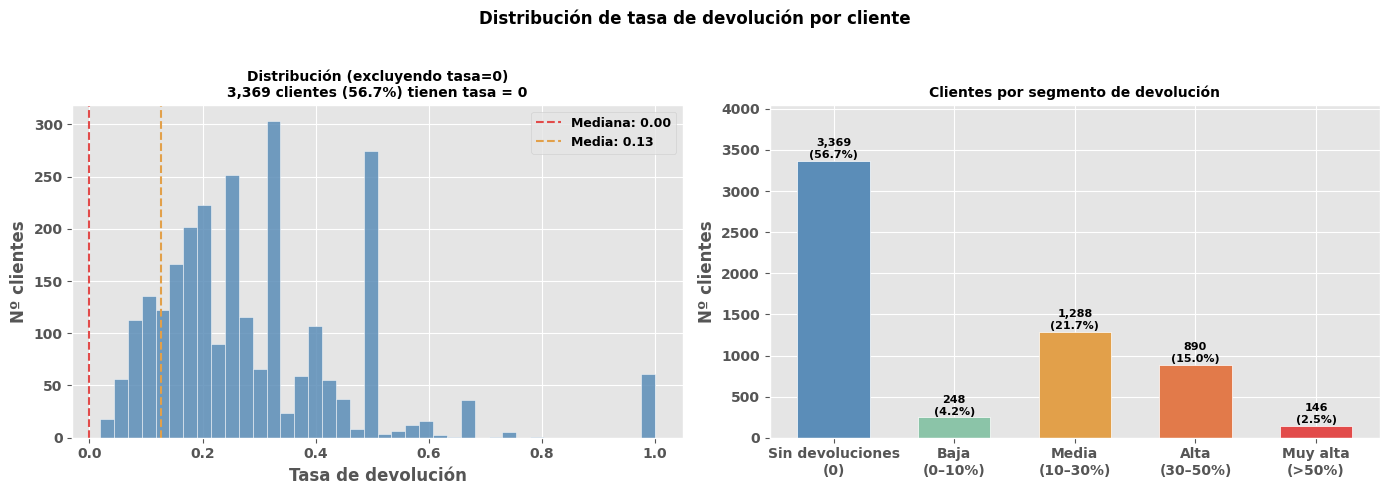

count           5941.00
mean               0.13
std                0.19
min                0.00
25%                0.00
50%                0.00
75%                0.22
max                1.00
Name: tasa_devolucion, dtype: float64


In [205]:
# Distribución de tasa de devolución

# tasa_devolucion está en rfm como columna
tasa = tasa_devolucion['tasa_devolucion'].dropna()

# Crear segmentos para el análisis
bins   = [0, 0.001, 0.1, 0.3, 0.5, 1.01]
labels_seg = ['Sin devoluciones\n(0)', 'Baja\n(0–10%)', 
              'Media\n(10–30%)', 'Alta\n(30–50%)', 'Muy alta\n(>50%)']
colores_seg = ['#5B8DB8', '#8BC4A8', '#E2A04A', '#E27A4A', '#E24B4A']

segmentos = pd.cut(tasa, bins=bins, labels=labels_seg, include_lowest=True)
conteo    = segmentos.value_counts().reindex(labels_seg)
pct       = (conteo / conteo.sum() * 100).round(1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Histograma continuo ---
axes[0].hist(tasa[tasa > 0], bins=40, color='#5B8DB8', 
             edgecolor='white', linewidth=0.4, alpha=0.85)
axes[0].axvline(tasa.median(), color='#E24B4A', linestyle='--', linewidth=1.5,
                label=f'Mediana: {tasa.median():.2f}')
axes[0].axvline(tasa.mean(),   color='#E2A04A', linestyle='--', linewidth=1.5,
                label=f'Media: {tasa.mean():.2f}')
axes[0].set_xlabel('Tasa de devolución')
axes[0].set_ylabel('Nº clientes')
axes[0].set_title(f'Distribución (excluyendo tasa=0)\n'
                  f'{(tasa == 0).sum():,} clientes ({(tasa==0).mean()*100:.1f}%) '
                  f'tienen tasa = 0',
                  fontsize=10)
axes[0].legend(fontsize=9)

# --- Barras por segmento ---
bars = axes[1].bar(labels_seg, conteo.values, color=colores_seg, 
                   width=0.6, edgecolor='white')
for bar, val, p in zip(bars, conteo.values, pct.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
                 f'{val:,}\n({p}%)', ha='center', va='bottom', fontsize=8)
axes[1].set_ylabel('Nº clientes')
axes[1].set_title('Clientes por segmento de devolución', fontsize=10)
axes[1].set_ylim(0, conteo.max() * 1.2)

plt.suptitle('Distribución de tasa de devolución por cliente\n',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print(tasa.describe().round(3))

### LOG TRANSFORM

Las variables monetary y numero_de_compras presentan una distribución muy sesgada a la derecha: la mayoría de clientes tienen valores bajos, pero unos pocos alcanzan valores muy elevados. Esa asimetría penaliza los modelos de ML al dar excesivo peso a los extremos. Aplicar log1p comprime la escala y distribuye los valores de forma más simétrica, permitiendo que el modelo trate a todos los clientes con el mismo nivel de resolución independientemente de su magnitud. Los histogramas muestran el efecto de forma visual e inmediata.

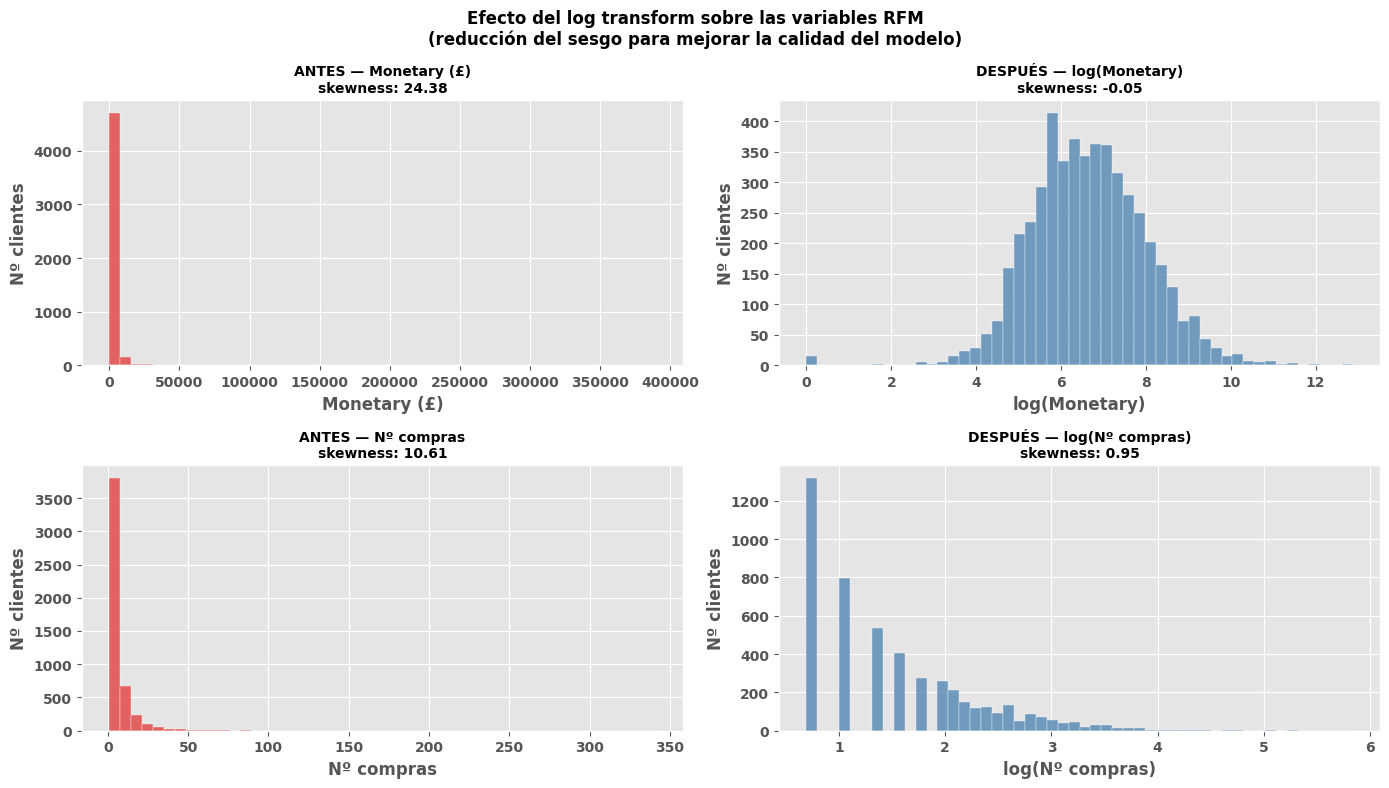

Monetary (£):
  Skewness original:    24.38
  Skewness tras log1p:  -0.05

Nº compras:
  Skewness original:    10.61
  Skewness tras log1p:  0.95



In [206]:
# Efecto del log transform

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

vars_plot = [
    ('monetary',          'Monetary (£)',  'log(Monetary)'),
    ('numero_de_compras', 'Nº compras',    'log(Nº compras)'),
]

for row_idx, (col_orig, label_orig, label_log) in enumerate(vars_plot):

    serie_orig = rfm[col_orig].dropna()
    serie_log  = np.log1p(serie_orig)

    skew_orig = serie_orig.skew()
    skew_log  = serie_log.skew()

    # Antes
    axes[row_idx][0].hist(serie_orig, bins=50, color='#E24B4A',
                          edgecolor='white', linewidth=0.3, alpha=0.85)
    axes[row_idx][0].set_title(f'ANTES — {label_orig}\nskewness: {skew_orig:.2f}', fontsize=10)
    axes[row_idx][0].set_xlabel(label_orig)
    axes[row_idx][0].set_ylabel('Nº clientes')

    # Después
    axes[row_idx][1].hist(serie_log, bins=50, color='#5B8DB8',
                          edgecolor='white', linewidth=0.3, alpha=0.85)
    axes[row_idx][1].set_title(f'DESPUÉS — {label_log}\nskewness: {skew_log:.2f}', fontsize=10)
    axes[row_idx][1].set_xlabel(label_log)
    axes[row_idx][1].set_ylabel('Nº clientes')

plt.suptitle('Efecto del log transform sobre las variables RFM\n'
             '(reducción del sesgo para mejorar la calidad del modelo)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

for col_orig, label, _ in vars_plot:
    serie = rfm[col_orig].dropna()
    print(f"{label}:")
    print(f"  Skewness original:    {serie.skew():.2f}")
    print(f"  Skewness tras log1p:  {np.log1p(serie).skew():.2f}\n")

## TRANSFORMACIONES

Hacemos las transformaciones para evitar el sesgo por las largas colas generadas por los datos y un standard scaler para que las variables tengan el mismo peso para el modelo

Por último separamos las variables predictoras (X) y la targer (Y)

In [207]:
rfm_trans = rfm.copy()
rfm_trans

,customer_id,ultima_compra,primera_compra,numero_de_compras,monetary,recency,dias_entre_pedidos,tasa_devolucion,invoice,target
1,12347,2011-04-07 10:43:00,2010-10-31 14:20:00,4,2434.96,63,52.33,0.00,4,1
2,12348,2011-04-05 10:47:00,2010-09-27 14:59:00,4,1709.40,65,63.00,0.00,4,1
3,12349,2010-10-28 08:23:00,2009-12-04 12:49:00,4,2646.99,224,109.00,0.20,4,1
4,12350,2011-02-02 16:01:00,2011-02-02 16:01:00,1,334.40,126,0.00,0.00,1,0
5,12351,2010-11-29 15:23:00,2010-11-29 15:23:00,1,300.93,191,0.00,0.00,1,0
...,...,...,...,...,...,...,...,...,...,...
5027,18283,2011-05-23 11:33:00,2010-02-19 17:16:00,11,1134.89,17,45.70,0.00,11,1
5028,18284,2010-10-06 12:31:00,2010-10-04 11:33:00,2,436.68,246,2.00,0.50,2,0
5029,18285,2010-02-17 10:24:00,2010-02-17 10:24:00,1,427.00,477,0.00,0.00,1,0
5030,18286,2010-08-20 11:57:00,2009-12-16 10:45:00,3,1188.43,293,123.50,0.33,3,0


In [208]:
list(rfm_trans.columns)

['customer_id',
 'ultima_compra',
 'primera_compra',
 'numero_de_compras',
 'monetary',
 'recency',
 'dias_entre_pedidos',
 'tasa_devolucion',
 'invoice',
 'target']

In [209]:
rfm_trans = rfm_trans.set_index('customer_id')
rfm_trans

,ultima_compra,primera_compra,numero_de_compras,monetary,recency,dias_entre_pedidos,tasa_devolucion,invoice,target
customer_id,,,,,,,,,
12347,2011-04-07 10:43:00,2010-10-31 14:20:00,4,2434.96,63,52.33,0.00,4,1
12348,2011-04-05 10:47:00,2010-09-27 14:59:00,4,1709.40,65,63.00,0.00,4,1
12349,2010-10-28 08:23:00,2009-12-04 12:49:00,4,2646.99,224,109.00,0.20,4,1
12350,2011-02-02 16:01:00,2011-02-02 16:01:00,1,334.40,126,0.00,0.00,1,0
12351,2010-11-29 15:23:00,2010-11-29 15:23:00,1,300.93,191,0.00,0.00,1,0
...,...,...,...,...,...,...,...,...,...
18283,2011-05-23 11:33:00,2010-02-19 17:16:00,11,1134.89,17,45.70,0.00,11,1
18284,2010-10-06 12:31:00,2010-10-04 11:33:00,2,436.68,246,2.00,0.50,2,0
18285,2010-02-17 10:24:00,2010-02-17 10:24:00,1,427.00,477,0.00,0.00,1,0


In [210]:
# Log transform para corregir skewness
rfm_log = rfm_trans.copy()
rfm_log['log_monetary']          = np.log1p(rfm_trans['monetary'])
rfm_log['log_numero_de_compras'] = np.log1p(rfm_trans['numero_de_compras'])
rfm_log

,ultima_compra,primera_compra,numero_de_compras,monetary,recency,dias_entre_pedidos,tasa_devolucion,invoice,target,log_monetary,log_numero_de_compras
customer_id,,,,,,,,,,,
12347,2011-04-07 10:43:00,2010-10-31 14:20:00,4,2434.96,63,52.33,0.00,4,1,7.80,1.61
12348,2011-04-05 10:47:00,2010-09-27 14:59:00,4,1709.40,65,63.00,0.00,4,1,7.44,1.61
12349,2010-10-28 08:23:00,2009-12-04 12:49:00,4,2646.99,224,109.00,0.20,4,1,7.88,1.61
12350,2011-02-02 16:01:00,2011-02-02 16:01:00,1,334.40,126,0.00,0.00,1,0,5.82,0.69
12351,2010-11-29 15:23:00,2010-11-29 15:23:00,1,300.93,191,0.00,0.00,1,0,5.71,0.69
...,...,...,...,...,...,...,...,...,...,...,...
18283,2011-05-23 11:33:00,2010-02-19 17:16:00,11,1134.89,17,45.70,0.00,11,1,7.04,2.48
18284,2010-10-06 12:31:00,2010-10-04 11:33:00,2,436.68,246,2.00,0.50,2,0,6.08,1.10
18285,2010-02-17 10:24:00,2010-02-17 10:24:00,1,427.00,477,0.00,0.00,1,0,6.06,0.69


In [211]:
# Variables a aplicar StandardScaler
var_ss = [
    'recency', 'dias_entre_pedidos', 'tasa_devolucion', 
    'invoice', 'log_monetary', 'log_numero_de_compras']

# Instanciamos 
ss = StandardScaler()

# Entrenamos y aplicamos
rfm_ss = ss.fit_transform(rfm_log[var_ss]) 

#Añadir sufijos a los nombres
nombres_ss = [variable + '_ss' for variable in var_ss]
#Guardar como dataframe
rfm_ss = pd.DataFrame(rfm_ss, columns=nombres_ss, index=rfm_log.index)
rfm_ss	

,recency_ss,dias_entre_pedidos_ss,tasa_devolucion_ss,invoice_ss,log_monetary_ss,log_numero_de_compras_ss
customer_id,,,,,,
12347,-0.73,0.04,-0.75,-0.19,0.84,0.04
12348,-0.71,0.20,-0.75,-0.19,0.58,0.04
12349,0.39,0.91,0.48,-0.19,0.90,0.04
12350,-0.29,-0.77,-0.75,-0.43,-0.61,-1.08
12351,0.16,-0.77,-0.75,-0.43,-0.68,-1.08
...,...,...,...,...,...,...
18283,-1.05,-0.07,-0.75,0.36,0.28,1.11
18284,0.54,-0.74,2.33,-0.35,-0.41,-0.58
18285,2.14,-0.77,-0.75,-0.43,-0.43,-1.08


In [212]:
# Filtrar columnas
var_eliminar = ['numero_de_compras',
                'monetary',
                'recency',
                'dias_entre_pedidos',
                'tasa_devolucion',
                'invoice',
                'target', 
                'log_monetary', 
                'log_numero_de_compras']

rfm_log = rfm_log.drop(columns=var_eliminar)
rfm_log

,ultima_compra,primera_compra
customer_id,,
12347,2011-04-07 10:43:00,2010-10-31 14:20:00
12348,2011-04-05 10:47:00,2010-09-27 14:59:00
12349,2010-10-28 08:23:00,2009-12-04 12:49:00
12350,2011-02-02 16:01:00,2011-02-02 16:01:00
12351,2010-11-29 15:23:00,2010-11-29 15:23:00
...,...,...
18283,2011-05-23 11:33:00,2010-02-19 17:16:00
18284,2010-10-06 12:31:00,2010-10-04 11:33:00
18285,2010-02-17 10:24:00,2010-02-17 10:24:00


In [213]:
rfm = pd.concat([rfm_log,rfm_ss,rfm_trans['target']],axis=1)
rfm

,ultima_compra,primera_compra,recency_ss,dias_entre_pedidos_ss,tasa_devolucion_ss,invoice_ss,log_monetary_ss,log_numero_de_compras_ss,target
customer_id,,,,,,,,,
12347,2011-04-07 10:43:00,2010-10-31 14:20:00,-0.73,0.04,-0.75,-0.19,0.84,0.04,1
12348,2011-04-05 10:47:00,2010-09-27 14:59:00,-0.71,0.20,-0.75,-0.19,0.58,0.04,1
12349,2010-10-28 08:23:00,2009-12-04 12:49:00,0.39,0.91,0.48,-0.19,0.90,0.04,1
12350,2011-02-02 16:01:00,2011-02-02 16:01:00,-0.29,-0.77,-0.75,-0.43,-0.61,-1.08,0
12351,2010-11-29 15:23:00,2010-11-29 15:23:00,0.16,-0.77,-0.75,-0.43,-0.68,-1.08,0
...,...,...,...,...,...,...,...,...,...
18283,2011-05-23 11:33:00,2010-02-19 17:16:00,-1.05,-0.07,-0.75,0.36,0.28,1.11,1
18284,2010-10-06 12:31:00,2010-10-04 11:33:00,0.54,-0.74,2.33,-0.35,-0.41,-0.58,0
18285,2010-02-17 10:24:00,2010-02-17 10:24:00,2.14,-0.77,-0.75,-0.43,-0.43,-1.08,0


In [214]:
x = rfm.iloc[:,2:8]
y = rfm['target']

## MODELIZAR

### ESTRATEGIA DE OPTIMIZACIÓN Y RESULTADOS

Hemos comparado tres estrategias de optimización de hiperparámetros probando los mismos algoritmos en cada una: Logistic Regression, Random Forest, XGBoost y HistGradientBoosting.

- Random Search -> AUC: 0.844 
- Grid Search -> AUC: 0.857
- Optuna -> AUC: 0.864 ← ganador

El resultado es que Optuna ha sido el mejor sistema de comparación para realizar una optimización bayesiana avanzada.

El resultado ha sido excepcional: hemos seleccionado un modelo basado en HistGradientBoosting optimizado con Optuna que alcanza un AUC de 0.864 en el dataset de validación. Esta mejora técnica se traduce en un impacto directo para el negocio:

1. Máxima Precisión: Con un AUC de 0.864, la capacidad del modelo para distinguir entre clientes con alta y baja propensión de compra es excelente, siendo el mejor resultado obtenido entre las tres estrategias de optimización.
2. Eficiencia en el Contacto: La curva de Lift confirma que en el primer 10% de la muestra (nuestros clientes con mayor puntuación), el modelo es más del doble de eficiente (2.0x) que un contacto realizado al azar.
3. Optimización del ROI: Según la curva de Ganancia Acumulada, podemos capturar aproximadamente el 75% de los compradores potenciales contactando a menos de la mitad de nuestra base de datos (40%). Esto permite concentrar el presupuesto de marketing en los perfiles con retorno real, eliminando el gasto innecesario en clientes con baja probabilidad de conversión.

| Métrica | Valor | Impacto |
| :--- | :--- | :--- |
| Algoritmo Ganador | HistGradientBoosting (Optuna) | Modelo de alta velocidad y capacidad no lineal. |
| AUC Final | 0.864 | Seguridad muy alta en la clasificación de prospectos. |
| Lift (Top 10%) | ~2.0x | Doblamos la tasa de éxito en el segmento prioritario. |
| Ganancia (40%) | ~75% | Capturamos 3 de cada 4 ventas con menos del 50% de esfuerzo. |

#### Reservar el dataset de validacion que será el mismo para todos los optimizadores

In [215]:
train_x,val_x,train_y,val_y = train_test_split(x,y,test_size=0.3)

### OPTIMIZACIÓN RANDOM SEARCH

#### Crear el pipe y el diccionario de algorimos, parámetros y valores a testar

In [216]:
pipe = Pipeline([('algoritmo',RandomForestClassifier())])

grid = [{'algoritmo': [LogisticRegression()],
         'algoritmo__n_jobs': [-1],
         'algoritmo__solver': ['saga'],
         'algoritmo__penalty': ['elasticnet', 'l1', 'l2', 'none'],
         'algoritmo__C': [0,0.25,0.5,0.75,1]},
        
        {'algoritmo': [RandomForestClassifier()],
         'algoritmo__n_jobs': [-1],
         'algoritmo__max_depth': [5,10,15],
         'algoritmo__n_estimators': [50,100,200]},
        
        {'algoritmo': [XGBClassifier()],
         'algoritmo__n_jobs': [-1],
         'algoritmo__verbosity': [0],#para que no salgan warnings
         'algoritmo__learning_rate': [0.01,0.025,0.05,0.1],
         'algoritmo__max_depth': [5,10,20],
         'algoritmo__reg_alpha': [0,0.1,0.5,1],
         'algoritmo__reg_lambda': [0.01,0.1,1],
         'algoritmo__n_estimators': [100,500,1000]},
        
        {'algoritmo': [HistGradientBoostingClassifier()],
         'algoritmo__learning_rate': [0.01,0.025,0.05,0.1],
         'algoritmo__max_iter': [50,100,200],
         'algoritmo__max_depth': [5,10,20],
         'algoritmo__min_samples_leaf': [500],
         'algoritmo__scoring': ['roc_auc'],
         'algoritmo__l2_regularization': [0,0.25,0.5,0.75,1]}
       ]

#### Hiperparametrecización Random Search

In [217]:
#Podemos cambiar el numero de iteraciones y la métrica para que nos de el scoring por si consiguieramos mejores resultados
random_search = RandomizedSearchCV(estimator = pipe,
                                   param_distributions = grid, 
                                   n_iter = 5, 
                                   cv = 3, 
                                   scoring = 'roc_auc', 
                                   verbose = 0,
                                   n_jobs = -1)

modelo_rs = random_search.fit(train_x,train_y)

pd.DataFrame(random_search.cv_results_).sort_values(by = 'rank_test_score')
#Debemos mirar el valor de la columna mean_test_score para compararlo con AUC que nos salga sobre val_y

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_algoritmo__verbosity,param_algoritmo__reg_lambda,param_algoritmo__reg_alpha,param_algoritmo__n_jobs,param_algoritmo__n_estimators,param_algoritmo__max_depth,param_algoritmo__learning_rate,param_algoritmo,param_algoritmo__scoring,param_algoritmo__min_samples_leaf,param_algoritmo__max_iter,param_algoritmo__l2_regularization,params,split0_test_score,split1_test_score,split2_test_score,mean_test_score,std_test_score,rank_test_score
3,3.76,0.48,0.02,0.00,0.00,0.10,1.00,-1.00,500.00,20,0.10,"XGBClassifier(base_score=None, booster=None, callbacks=None,\n colsample_bylevel=None, colsample_bynode=None,\n colsample_bytree=None, device=None, early_stopping_rounds=None,\n enable_categorical=False, eval_metric=None, feature_types=None,\n feature_weights=None, gamma=None, grow_policy=None,\n importance_type=None, interaction_constraints=None,\n learning_rate=None, max_bin=None, max_cat_threshold=None,\n max_cat_to_onehot=None, max_delta_step=None, max_depth=None,\n max_leaves=None, min_child_weight=None, missing=nan,\n monotone_constraints=None, multi_strategy=None, n_estimators=None,\n n_jobs=None, num_parallel_tree=None, ...)",NaN,NaN,NaN,NaN,"{'algoritmo__verbosity': 0, 'algoritmo__reg_lambda': 0.1, 'algoritmo__reg_alpha': 1, 'algoritmo__n_jobs': -1, 'algoritmo__n_estimators': 500, 'algoritmo__max_depth': 20, 'algoritmo__learning_rate': 0.1, 'algoritmo': XGBClassifier(base_score=None, booster=None, callbacks=None, colsample_bylevel=None, colsample_bynode=None, colsample_bytree=None, device=None, early_stopping_rounds=None, enable_categorical=False, eval_metric=None, feature_types=None, feature_weights=None, gamma=None, grow_policy=None, importance_type=None, interaction_constraints=None, learning_rate=None, max_bin=None, max_cat_threshold=None, max_cat_to_onehot=None, max_delta_step=None, max_depth=None, max_leaves=None, min_child_weight=None, missing=nan, monotone_constraints=None, multi_strategy=None, n_estimators=None, n_jobs=None, num_parallel_tree=None, ...)}",0.83,0.84,0.83,0.83,0.01,1
4,3.33,0.28,0.03,0.00,0.00,0.01,0.50,-1.00,500.00,10,0.05,"XGBClassifier(base_score=None, booster=None, callbacks=None,\n colsample_bylevel=None, colsample_bynode=None,\n colsample_bytree=None, device=None, early_stopping_rounds=None,\n enable_categorical=False, eval_metric=None, feature_types=None,\n feature_weights=None, gamma=None, grow_policy=None,\n importance_type=None, interaction_constraints=None,\n learning_rate=None, max_bin=None, max_cat_threshold=None,\n max_cat_to_onehot=None, max_delta_step=None, max_depth=None,\n max_leaves=None, min_child_weight=None, missing=nan,\n monotone_constraints=None, multi_strategy=None, n_estimators=None,\n n_jobs=None, num_parallel_tree=None, ...)",NaN,NaN,NaN,NaN,"{'algoritmo__verbosity': 0, 'algoritmo__reg_lambda': 0.01, 'algoritmo__reg_alpha': 0.5, 'algoritmo__n_jobs': -1, 'algoritmo__n_estimators': 500, 'algoritmo__max_depth': 10, 'algoritmo__learning_rate': 0.05, 'algoritmo': XGBClassifier(base_score=None, booster=None, callbacks=None, colsample_bylevel=None, colsample_bynode=None, colsample_bytree=None, device=None, early_stopping_rounds=None, enable_categorical=False, eval_metric=None, feature_types=None, feature_weights=None, gamma=None, grow_policy=None, importance_type=None, interaction_constraints=None, learning_rate=None, max_bin=None, max_cat_threshold=None, max_cat_to_onehot=None, max_delta_step=None, max_depth=None, max_leaves=None, min_child_weight=None, missing=nan, monotone_constraints=None, multi_strategy=None, n_estimators=None, n_jobs=None, num_parallel_tree=None, ...)}",0.83,0.84,0.83,0.83,0.01,2
2,5.31,1.48,0.04,0.01,0.00,0.01,0.10,-1.00,500.00,20,0.03,"XGBClassifier(base_score=None, booster=None, callbacks=None,\n colsample_bylevel=None, colsample_bynode=None,\n colsample_bytree=None, device=None, early_stopping_rounds=None,\n enable_categorical=False, eval_metric=None, feature_types=None,\n feature_weights=None, gamma=

#### Evaluar

In [218]:
# Predecir sobre validación
pred = modelo_rs.best_estimator_.predict_proba(val_x)[:, 1]

In [219]:
# Evaluar sobre validación
roc_auc_score(val_y, pred)
#Comparamos con el valor de mean_test_score. Si sale un AUC mucho mas bajo sobre val_y que sobre train = SOBREAJUSTE 

0.84489764025629

#### Examinar el mejor modelo

In [220]:
#Representación visual de un pipeline
from sklearn import set_config
set_config(display = 'text')
pd.set_option('display.max_colwidth', None)
modelo_rs.best_estimator_

Pipeline(steps=[('algoritmo',
                 XGBClassifier(base_score=None, booster=None, callbacks=None,
                               colsample_bylevel=None, colsample_bynode=None,
                               colsample_bytree=None, device=None,
                               early_stopping_rounds=None,
                               enable_categorical=False, eval_metric=None,
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.1,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=20, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy

In [221]:
modelo_rs.best_estimator_.named_steps['algoritmo'].get_params()

{'objective': 'binary:logistic',
 'base_score': None,
 'booster': None,
 'callbacks': None,
 'colsample_bylevel': None,
 'colsample_bynode': None,
 'colsample_bytree': None,
 'device': None,
 'early_stopping_rounds': None,
 'enable_categorical': False,
 'eval_metric': None,
 'feature_types': None,
 'feature_weights': None,
 'gamma': None,
 'grow_policy': None,
 'importance_type': None,
 'interaction_constraints': None,
 'learning_rate': 0.1,
 'max_bin': None,
 'max_cat_threshold': None,
 'max_cat_to_onehot': None,
 'max_delta_step': None,
 'max_depth': 20,
 'max_leaves': None,
 'min_child_weight': None,
 'missing': nan,
 'monotone_constraints': None,
 'multi_strategy': None,
 'n_estimators': 500,
 'n_jobs': -1,
 'num_parallel_tree': None,
 'random_state': None,
 'reg_alpha': 1,
 'reg_lambda': 0.1,
 'sampling_method': None,
 'scale_pos_weight': None,
 'subsample': None,
 'tree_method': None,
 'validate_parameters': None,
 'verbosity': 0}

#### REPORTING DEL MODELO

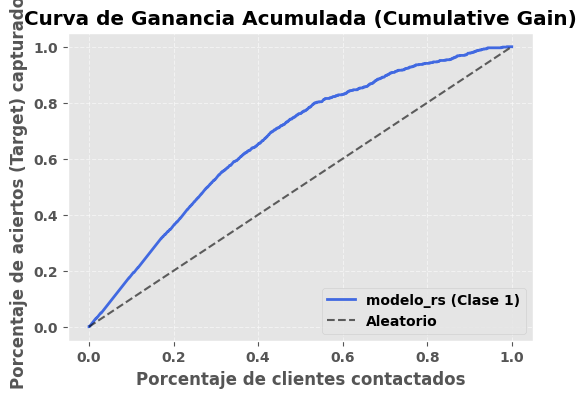

In [222]:
# GAIN CHART

# 1. Obtenemos las probabilidades de la clase positiva (1)
# 'val_x' son tus datos de validación ya escalados
y_probas = modelo_rs.best_estimator_.predict_proba(val_x)[:, 1]

# 2. Ordenamos los valores reales (val_y) según las probabilidades de mayor a menor
indices_ordenados = np.argsort(y_probas)[::-1]
y_real_ordenado = val_y.values[indices_ordenados]

# 3. Calculamos el porcentaje acumulado de aciertos (Ganancia)
# np.cumsum suma los aciertos conforme avanzamos en la lista
ganancia_acumulada = np.cumsum(y_real_ordenado) / np.sum(y_real_ordenado)

# 4. Creamos el eje X (porcentaje de la población de 0 a 1)
porcentaje_poblacion = np.arange(1, len(val_y) + 1) / len(val_y)

# 5. Graficamos
fig, ax = plt.subplots(figsize=(6, 4))

# Añadimos el punto (0,0) para que la curva salga del origen
ax.plot(np.insert(porcentaje_poblacion, 0, 0), np.insert(ganancia_acumulada, 0, 0), 
        label='modelo_rs (Clase 1)', color='royalblue', lw=2)

# Línea base (Aleatorio): una diagonal de 0 a 1
ax.plot([0, 1], [0, 1], 'k--', label='Aleatorio', alpha=0.6)

# Configuración estética
ax.set_title('Curva de Ganancia Acumulada (Cumulative Gain)')
ax.set_xlabel('Porcentaje de clientes contactados')
ax.set_ylabel('Porcentaje de aciertos (Target) capturados')
ax.legend(loc='lower right')
ax.grid(True, linestyle='--', alpha=0.5)

plt.show()

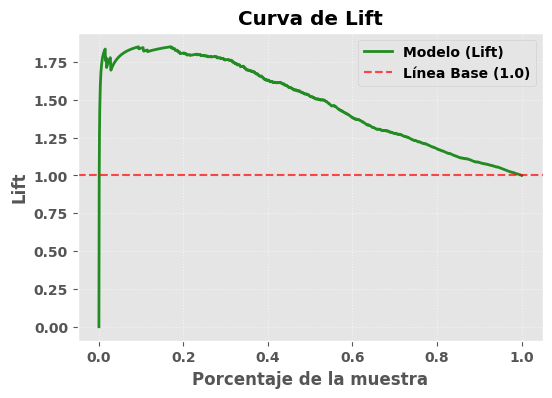

In [223]:
# LIFT CHART

# 1. Probabilidades y ordenación
y_probas = modelo_rs.best_estimator_.predict_proba(val_x)[:, 1]
indices = np.argsort(y_probas)[::-1]
y_real_ordenado = val_y.values[indices]

# 2. Cálculo de la tasa de respuesta acumulada vs tasa base
tasa_respuesta_acumulada = np.cumsum(y_real_ordenado) / np.arange(1, len(val_y) + 1)
tasa_base = np.mean(val_y)

# 3. El Lift es la relación entre ambas
lift = tasa_respuesta_acumulada / tasa_base

# 4. Eje X (porcentaje de la población)
porcentaje_poblacion = np.arange(1, len(val_y) + 1) / len(val_y)

# 5. Gráfico
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(porcentaje_poblacion, lift, label='Modelo (Lift)', color='forestgreen', lw=2)

# Línea base de Lift = 1 (equivalente al azar)
ax.axhline(y=1, color='red', linestyle='--', label='Línea Base (1.0)', alpha=0.7)

ax.set_title('Curva de Lift')
ax.set_xlabel('Porcentaje de la muestra')
ax.set_ylabel('Lift')
ax.legend()
ax.grid(True, linestyle=':', alpha=0.6)

plt.show()

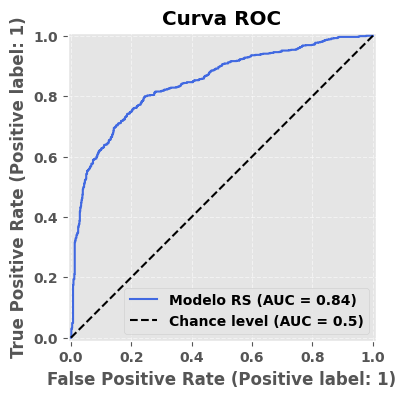

In [224]:
# ROC CHART

# 1. Creamos la figura
fig, ax = plt.subplots(figsize=(6, 4))

# 2. Usamos el visualizador nativo de sklearn
# Esto dibuja la curva ROC y la línea punteada de azar automáticamente
RocCurveDisplay.from_estimator(
    modelo_rs.best_estimator_, 
    val_x, 
    val_y, 
    ax=ax, 
    name='Modelo RS',           # Nombre que saldrá en la leyenda
    color='royalblue',       # Color de la línea
    plot_chance_level=True   # Dibuja la línea punteada diagonal (azar)
)

# 3. Personalización estética
ax.set_title('Curva ROC')
ax.grid(True, linestyle='--', alpha=0.5)

plt.show()

### OPTIMIZACIÓN GRID SEARCH

#### Reservar el dataset de validacion

#### Crear el pipe y el diccionario de algorimos, parámetros y valores a testar

In [225]:
pipe = Pipeline([('algoritmo',RandomForestClassifier())])

grid = [{'algoritmo': [LogisticRegression()],
         'algoritmo__n_jobs': [-1],
         'algoritmo__solver': ['saga'],
         'algoritmo__penalty': ['elasticnet', 'l1', 'l2', 'none'],
         'algoritmo__C': [0,0.25,0.5,0.75,1]},
        
        {'algoritmo': [RandomForestClassifier()],
         'algoritmo__n_jobs': [-1],
         'algoritmo__max_depth': [5,10,15],
         'algoritmo__n_estimators': [50,100,200]},
        
        {'algoritmo': [XGBClassifier()],
         'algoritmo__n_jobs': [-1],
         'algoritmo__verbosity': [0],#para que no salgan warnings
         'algoritmo__learning_rate': [0.01,0.025,0.05,0.1],
         'algoritmo__max_depth': [5,10,20],
         'algoritmo__reg_alpha': [0,0.1,0.5,1],
         'algoritmo__reg_lambda': [0.01,0.1,1],
         'algoritmo__n_estimators': [100,500,1000]},
        
        {'algoritmo': [HistGradientBoostingClassifier()],
         'algoritmo__learning_rate': [0.01,0.025,0.05,0.1],
         'algoritmo__max_iter': [50,100,200],
         'algoritmo__max_depth': [5,10,20],
         'algoritmo__min_samples_leaf': [500],
         'algoritmo__scoring': ['roc_auc'],
         'algoritmo__l2_regularization': [0,0.25,0.5,0.75,1]}
       ]

#### Hiperparametrecización Grid Search

In [226]:
grid_search = GridSearchCV(estimator= pipe, 
                            param_grid = grid, 
                            cv = 3, 
                            scoring = 'roc_auc',
                            verbose = 0,
                            n_jobs = -1)

modelo_gs = grid_search.fit(train_x,train_y)

pd.DataFrame(grid_search.cv_results_).sort_values(by = 'rank_test_score')

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_algoritmo,param_algoritmo__C,param_algoritmo__n_jobs,param_algoritmo__penalty,param_algoritmo__solver,param_algoritmo__max_depth,param_algoritmo__n_estimators,param_algoritmo__learning_rate,param_algoritmo__reg_alpha,param_algoritmo__reg_lambda,param_algoritmo__verbosity,param_algoritmo__l2_regularization,param_algoritmo__max_iter,param_algoritmo__min_samples_leaf,param_algoritmo__scoring,params,split0_test_score,split1_test_score,split2_test_score,mean_test_score,std_test_score,rank_test_score
363,0.53,0.10,0.01,0.00,"XGBClassifier(base_score=None, booster=None, callbacks=None,\n colsample_bylevel=None, colsample_bynode=None,\n colsample_bytree=None, device=None, early_stopping_rounds=None,\n enable_categorical=False, eval_metric=None, feature_types=None,\n feature_weights=None, gamma=None, grow_policy=None,\n importance_type=None, interaction_constraints=None,\n learning_rate=None, max_bin=None, max_cat_threshold=None,\n max_cat_to_onehot=None, max_delta_step=None, max_depth=None,\n max_leaves=None, min_child_weight=None, missing=nan,\n monotone_constraints=None, multi_strategy=None, n_estimators=None,\n n_jobs=None, num_parallel_tree=None, ...)",NaN,-1.00,NaN,NaN,5.00,100.00,0.10,1.00,0.10,0.00,NaN,NaN,NaN,NaN,"{'algoritmo': XGBClassifier(base_score=None, booster=None, callbacks=None, colsample_bylevel=None, colsample_bynode=None, colsample_bytree=None, device=None, early_stopping_rounds=None, enable_categorical=False, eval_metric=None, feature_types=None, feature_weights=None, gamma=None, grow_policy=None, importance_type=None, interaction_constraints=None, learning_rate=None, max_bin=None, max_cat_threshold=None, max_cat_to_onehot=None, max_delta_step=None, max_depth=None, max_leaves=None, min_child_weight=None, missing=nan, monotone_constraints=None, multi_strategy=None, n_estimators=None, n_jobs=None, num_parallel_tree=None, ...), 'algoritmo__learning_rate': 0.1, 'algoritmo__max_depth': 5, 'algoritmo__n_estimators': 100, 'algoritmo__n_jobs': -1, 'algoritmo__reg_alpha': 1, 'algoritmo__reg_lambda': 0.1, 'algoritmo__verbosity': 0}",0.84,0.85,0.84,0.85,0.00,1
156,2.50,0.19,0.02,0.00,"XGBClassifier(base_score=None, booster=None, callbacks=None,\n colsample_bylevel=None, colsample_bynode=None,\n colsample_bytree=None, device=None, early_stopping_rounds=None,\n enable_categorical=False, eval_metric=None, feature_types=None,\n feature_weights=None, gamma=None, grow_policy=None,\n importance_type=None, interaction_constraints=None,\n learning_rate=None, max_bin=None, max_cat_threshold=None,\n max_cat_to_onehot=None, max_delta_step=None, max_depth=None,\n max_leaves=None, min_child_weight=None, missing=nan,\n monotone_constraints=None, multi_strategy=None, n_estimators=None,\n n_jobs=None, num_parallel_tree=None, ...)",NaN,-1.00,NaN,NaN,5.00,500.00,0.03,0.50,0.10,0.00,NaN,NaN,NaN,NaN,"{'algoritmo': XGBClassifier(base_score=None, booster=None, callbacks=None, colsample_bylevel=None, colsample_bynode=None, colsample_bytree=None, device=None, early_stopping_rounds=None, enable_categorical=False, eval_metric=None, feature_types=None, feature_weights=None, gamma=None, grow_policy=None, importance_type=None, interaction_constraints=None, learning_rate=None, max_bin=None, max_cat_threshold=None, max_cat_to_onehot=None, max_delta_step=None, max_depth=None, max_leaves=None, min_child_weight=None, missing=nan, monotone_constraints=None, multi_strategy=None, n_estimators=None, n_jobs=None, num_parallel_tree=None, ...), 'algoritmo__learning_rate': 0.025, 'algoritmo__max_depth': 5, 'algoritmo__n_estimators': 500, 'algoritmo__n_jobs': -1, 'algoritmo__reg_alpha': 0.5, 'algoritmo__reg_lambda': 0.1, 'algoritmo__verbosity': 0}",0.85,0.85,0.84,0.85,0.00,2
149,2.01,0.04,0.02,0.00,"XGBClassifier(base_score=None, booster=None, callbacks=None,\n colsample_bylevel=None, colsample_bynode=None,\n colsample_bytree=None, device=None, early_stopping_rounds=None,\n enable_categorical=False, eval

#### Evaluar

In [227]:
# Predecir sobre validación
pred = modelo_gs.best_estimator_.predict_proba(val_x)[:, 1]

In [228]:
# Evaluar sobre validación
roc_auc_score(val_y, pred)
#Comparamos con el valor de mean_test_score. Si sale un AUC mucho mas bajo sobre val_y que sobre train = SOBREAJUSTE 

0.8575149823555279

#### Examinar el mejor modelo

In [229]:
#Representación visual de un pipeline
from sklearn import set_config
set_config(display = 'text')
pd.set_option('display.max_colwidth', None)
modelo_gs.best_estimator_

Pipeline(steps=[('algoritmo',
                 XGBClassifier(base_score=None, booster=None, callbacks=None,
                               colsample_bylevel=None, colsample_bynode=None,
                               colsample_bytree=None, device=None,
                               early_stopping_rounds=None,
                               enable_categorical=False, eval_metric=None,
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.1,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=5, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=

In [230]:
modelo_gs.best_estimator_.named_steps['algoritmo'].get_params()

{'objective': 'binary:logistic',
 'base_score': None,
 'booster': None,
 'callbacks': None,
 'colsample_bylevel': None,
 'colsample_bynode': None,
 'colsample_bytree': None,
 'device': None,
 'early_stopping_rounds': None,
 'enable_categorical': False,
 'eval_metric': None,
 'feature_types': None,
 'feature_weights': None,
 'gamma': None,
 'grow_policy': None,
 'importance_type': None,
 'interaction_constraints': None,
 'learning_rate': 0.1,
 'max_bin': None,
 'max_cat_threshold': None,
 'max_cat_to_onehot': None,
 'max_delta_step': None,
 'max_depth': 5,
 'max_leaves': None,
 'min_child_weight': None,
 'missing': nan,
 'monotone_constraints': None,
 'multi_strategy': None,
 'n_estimators': 100,
 'n_jobs': -1,
 'num_parallel_tree': None,
 'random_state': None,
 'reg_alpha': 1,
 'reg_lambda': 0.1,
 'sampling_method': None,
 'scale_pos_weight': None,
 'subsample': None,
 'tree_method': None,
 'validate_parameters': None,
 'verbosity': 0}

#### REPORTING DEL MODELO

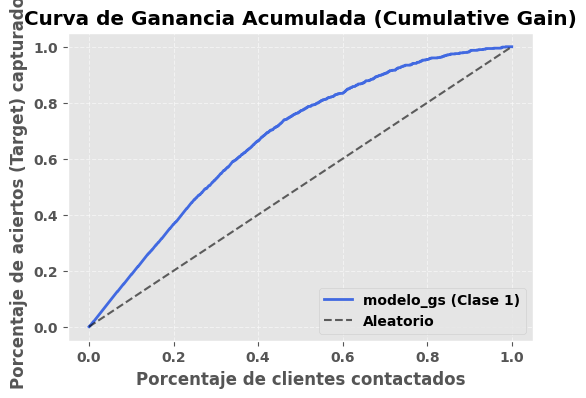

In [231]:
# GAIN CHART

# 1. Obtenemos las probabilidades de la clase positiva (1)
# 'val_x' son tus datos de validación ya escalados
y_probas = modelo_gs.best_estimator_.predict_proba(val_x)[:, 1]

# 2. Ordenamos los valores reales (val_y) según las probabilidades de mayor a menor
indices_ordenados = np.argsort(y_probas)[::-1]
y_real_ordenado = val_y.values[indices_ordenados]

# 3. Calculamos el porcentaje acumulado de aciertos (Ganancia)
# np.cumsum suma los aciertos conforme avanzamos en la lista
ganancia_acumulada = np.cumsum(y_real_ordenado) / np.sum(y_real_ordenado)

# 4. Creamos el eje X (porcentaje de la población de 0 a 1)
porcentaje_poblacion = np.arange(1, len(val_y) + 1) / len(val_y)

# 5. Graficamos
fig, ax = plt.subplots(figsize=(6, 4))

# Añadimos el punto (0,0) para que la curva salga del origen
ax.plot(np.insert(porcentaje_poblacion, 0, 0), np.insert(ganancia_acumulada, 0, 0), 
        label='modelo_gs (Clase 1)', color='royalblue', lw=2)

# Línea base (Aleatorio): una diagonal de 0 a 1
ax.plot([0, 1], [0, 1], 'k--', label='Aleatorio', alpha=0.6)

# Configuración estética
ax.set_title('Curva de Ganancia Acumulada (Cumulative Gain)')
ax.set_xlabel('Porcentaje de clientes contactados')
ax.set_ylabel('Porcentaje de aciertos (Target) capturados')
ax.legend(loc='lower right')
ax.grid(True, linestyle='--', alpha=0.5)

plt.show()

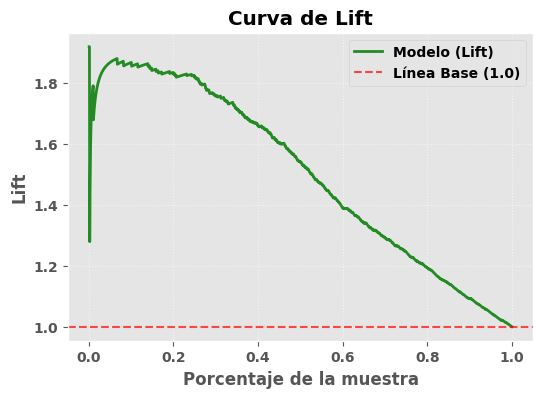

In [232]:
# LIFT CHART

# 1. Probabilidades y ordenación
y_probas = modelo_gs.best_estimator_.predict_proba(val_x)[:, 1]
indices = np.argsort(y_probas)[::-1]
y_real_ordenado = val_y.values[indices]

# 2. Cálculo de la tasa de respuesta acumulada vs tasa base
tasa_respuesta_acumulada = np.cumsum(y_real_ordenado) / np.arange(1, len(val_y) + 1)
tasa_base = np.mean(val_y)

# 3. El Lift es la relación entre ambas
lift = tasa_respuesta_acumulada / tasa_base

# 4. Eje X (porcentaje de la población)
porcentaje_poblacion = np.arange(1, len(val_y) + 1) / len(val_y)

# 5. Gráfico
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(porcentaje_poblacion, lift, label='Modelo (Lift)', color='forestgreen', lw=2)

# Línea base de Lift = 1 (equivalente al azar)
ax.axhline(y=1, color='red', linestyle='--', label='Línea Base (1.0)', alpha=0.7)

ax.set_title('Curva de Lift')
ax.set_xlabel('Porcentaje de la muestra')
ax.set_ylabel('Lift')
ax.legend()
ax.grid(True, linestyle=':', alpha=0.6)

plt.show()

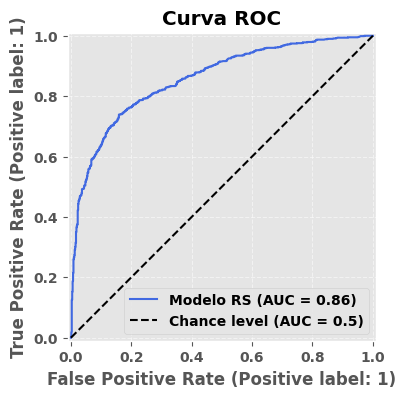

In [233]:
# ROC CHART

# 1. Creamos la figura
fig, ax = plt.subplots(figsize=(6, 4))

# 2. Usamos el visualizador nativo de sklearn
# Esto dibuja la curva ROC y la línea punteada de azar automáticamente
RocCurveDisplay.from_estimator(
    modelo_gs.best_estimator_, 
    val_x, 
    val_y, 
    ax=ax, 
    name='Modelo RS',           # Nombre que saldrá en la leyenda
    color='royalblue',       # Color de la línea
    plot_chance_level=True   # Dibuja la línea punteada diagonal (azar)
)

# 3. Personalización estética
ax.set_title('Curva ROC')
ax.grid(True, linestyle='--', alpha=0.5)

plt.show()

### OPTIMIZACION OPTUNA

#### Crear el pipe y el diccionario de algorimos, parámetros y valores a testar

In [234]:
def objective(trial):
    # Seleccionamos el algoritmo (como hacías en el grid)
    classifier_name = trial.suggest_categorical("algoritmo", ["LogisticRegression", "RandomForest", "XGBoost", "HistGradientBoosting"])
    
    if classifier_name == "LogisticRegression":
        model = LogisticRegression(
            solver='saga',
            penalty=trial.suggest_categorical("lr_penalty", ['l1', 'l2']),
            C=trial.suggest_float("lr_C", 0.1, 1.0),
            n_jobs=-1
        )
    elif classifier_name == "RandomForest":
        model = RandomForestClassifier(
            max_depth=trial.suggest_int("rf_max_depth", 5, 15),
            n_estimators=trial.suggest_int("rf_n_estimators", 50, 200),
            n_jobs=-1
        )
    elif classifier_name == "XGBoost":
        model = XGBClassifier(
            learning_rate=trial.suggest_float("xgb_lr", 0.01, 0.1, log=True),
            max_depth=trial.suggest_int("xgb_max_depth", 5, 20),
            n_estimators=trial.suggest_int("xgb_n_estimators", 100, 1000),
            verbosity=0,
            n_jobs=-1
        )
    else:
        model = HistGradientBoostingClassifier(
            learning_rate=trial.suggest_float("hgb_lr", 0.01, 0.1),
            max_iter=trial.suggest_int("hgb_iter", 50, 200)
        )

    # El score que Optuna intentará maximizar
    score = cross_val_score(model, train_x, train_y, cv=3, scoring='roc_auc').mean()
    return score

# CREAR EL ESTUDIO (Equivale a configurar el RandomizedSearchCV)
study = optuna.create_study(direction="maximize")

# EJECUTAR (Equivale al .fit() del RandomizedSearchCV)
study.optimize(objective, n_trials=20)

[I 2026-03-26 13:17:06,393] A new study created in memory with name: no-name-995828ee-1482-43e9-b8b6-0a6a7ef5c1c1
[I 2026-03-26 13:17:07,290] Trial 0 finished with value: 0.8273881991321118 and parameters: {'algoritmo': 'RandomForest', 'rf_max_depth': 5, 'rf_n_estimators': 79}. Best is trial 0 with value: 0.8273881991321118.
[I 2026-03-26 13:17:08,910] Trial 1 finished with value: 0.8298873955319833 and parameters: {'algoritmo': 'RandomForest', 'rf_max_depth': 5, 'rf_n_estimators': 158}. Best is trial 1 with value: 0.8298873955319833.
[I 2026-03-26 13:17:12,068] Trial 2 finished with value: 0.8395923738347797 and parameters: {'algoritmo': 'XGBoost', 'xgb_lr': 0.02270662785110519, 'xgb_max_depth': 13, 'xgb_n_estimators': 390}. Best is trial 2 with value: 0.8395923738347797.
[I 2026-03-26 13:17:12,249] Trial 3 finished with value: 0.8066317100610737 and parameters: {'algoritmo': 'LogisticRegression', 'lr_penalty': 'l2', 'lr_C': 0.9623647269105328}. Best is trial 2 with value: 0.839592373

In [235]:
# 1. Extraer mejores parámetros y el nombre del algoritmo
params = study.best_params
best_algo = params.pop('algoritmo')

# 2. Limpiar los prefijos de los parámetros (ej: de 'hgb_lr' a 'learning_rate')
# Esta lógica adapta los nombres de Optuna a los que espera Scikit-Learn
if best_algo == "LogisticRegression":
    clean_params = {k.replace('lr_', ''): v for k, v in params.items() if k.startswith('lr_')}
    algo_final = LogisticRegression(**clean_params, solver='saga', n_jobs=-1)
    
elif best_algo == "RandomForest":
    clean_params = {k.replace('rf_', ''): v for k, v in params.items() if k.startswith('rf_')}
    algo_final = RandomForestClassifier(**clean_params, n_jobs=-1)
    
elif best_algo == "XGBoost":
    clean_params = {k.replace('xgb_', ''): v for k, v in params.items() if k.startswith('xgb_')}
    algo_final = XGBClassifier(**clean_params, n_jobs=-1)
    
elif best_algo == "HistGradientBoosting":
    # Mapeo especial para HistGradientBoosting (iter -> max_iter / lr -> learning_rate)
    clean_params = {
        'learning_rate': params['hgb_lr'],
        'max_iter': params['hgb_iter']
    }
    algo_final = HistGradientBoostingClassifier(**clean_params)

# 3. Envolver en Pipeline con el nombre 'algoritmo' para compatibilidad total
modelo_op = Pipeline([('algoritmo', algo_final)])

# 4. Entrenar el modelo final
modelo_op.fit(train_x, train_y)

print(f"Modelo final configurado y entrenado: {best_algo}")

Modelo final configurado y entrenado: HistGradientBoosting


#### Evaluar

In [236]:
# Predecir sobre validación
pred = modelo_op.predict_proba(val_x)[:, 1]

In [237]:
# Evaluar sobre validación
roc_auc_score(val_y, pred)
#Comparamos con el valor de mean_test_score. Si sale un AUC mucho mas bajo sobre val_y que sobre train = SOBREAJUSTE 

0.8647354056048002

In [238]:
# Crea una tabla con todos los intentos
df_resultados = study.trials_dataframe()

# Ordena por el mejor valor (columna 'value')
df_resultados.sort_values(by='value', ascending=False).head()

# Recorremos todos los intentos (trials) realizados por Optuna
for trial in study.trials:
    # Imprimimos el número de iteración y el valor de la métrica (AUC)
    print(f"Interacción {trial.number}: AUC = {trial.value:.4f}")

Interacción 0: AUC = 0.8274
Interacción 1: AUC = 0.8299
Interacción 2: AUC = 0.8396
Interacción 3: AUC = 0.8066
Interacción 4: AUC = 0.8066
Interacción 5: AUC = 0.8375
Interacción 6: AUC = 0.8426
Interacción 7: AUC = 0.8496
Interacción 8: AUC = 0.8319
Interacción 9: AUC = 0.8066
Interacción 10: AUC = 0.8473
Interacción 11: AUC = 0.8460
Interacción 12: AUC = 0.8473
Interacción 13: AUC = 0.8485
Interacción 14: AUC = 0.8477
Interacción 15: AUC = 0.8501
Interacción 16: AUC = 0.8490
Interacción 17: AUC = 0.8447
Interacción 18: AUC = 0.8479
Interacción 19: AUC = 0.8205


#### REPORTING DEL MODELO

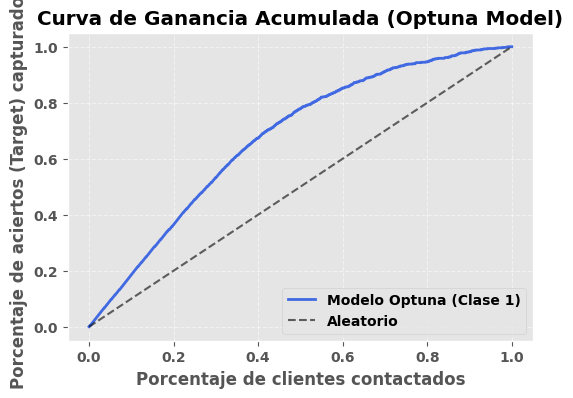

In [239]:
# GAIN CHART - ADAPTADO PARA OPTUNA

# 1. Obtenemos las probabilidades
# IMPORTANTE: Si usaste el Pipeline que te di, quita el .best_estimator_
# Si te da error, simplemente usa: y_probas = modelo_op.predict_proba(val_x)[:, 1]
try:
    y_probas = modelo_op.predict_proba(val_x)[:, 1]
except AttributeError:
    y_probas = modelo_op.best_estimator_.predict_proba(val_x)[:, 1]

# 2. Ordenamos los valores reales (val_y) según las probabilidades de mayor a menor
indices_ordenados = np.argsort(y_probas)[::-1]
y_real_ordenado = val_y.values[indices_ordenados]

# 3. Calculamos el porcentaje acumulado de aciertos (Ganancia)
ganancia_acumulada = np.cumsum(y_real_ordenado) / np.sum(y_real_ordenado)

# 4. Creamos el eje X (porcentaje de la población de 0 a 1)
porcentaje_poblacion = np.arange(1, len(val_y) + 1) / len(val_y)

# 5. Graficamos
fig, ax = plt.subplots(figsize=(6, 4))

# Añadimos el punto (0,0) para que la curva salga del origen
ax.plot(np.insert(porcentaje_poblacion, 0, 0), np.insert(ganancia_acumulada, 0, 0), 
        label='Modelo Optuna (Clase 1)', color='royalblue', lw=2)

# Línea base (Aleatorio)
ax.plot([0, 1], [0, 1], 'k--', label='Aleatorio', alpha=0.6)

# Configuración estética
ax.set_title('Curva de Ganancia Acumulada (Optuna Model)')
ax.set_xlabel('Porcentaje de clientes contactados')
ax.set_ylabel('Porcentaje de aciertos (Target) capturados')
ax.legend(loc='lower right')
ax.grid(True, linestyle='--', alpha=0.5)

plt.show()

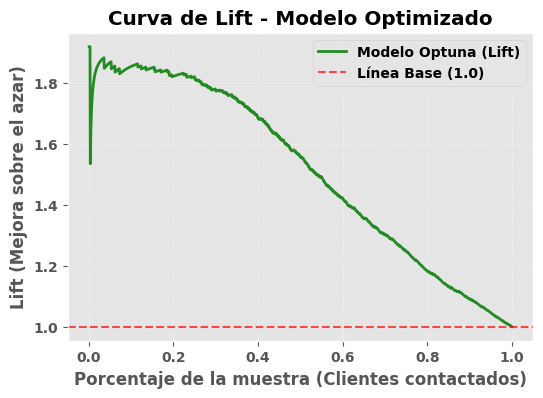

In [240]:
# LIFT CHART - ADAPTADO PARA OPTUNA

# 1. Probabilidades y ordenación
# Usamos directamente modelo_op. Si fuera un pipeline de sklearn antiguo usaría .best_estimator_
y_probas = modelo_op.predict_proba(val_x)[:, 1]
indices = np.argsort(y_probas)[::-1]
y_real_ordenado = val_y.values[indices]

# 2. Cálculo de la tasa de respuesta acumulada vs tasa base
# np.arange(1, ...) crea el conteo de clientes de 1 en 1
tasa_respuesta_acumulada = np.cumsum(y_real_ordenado) / np.arange(1, len(val_y) + 1)
tasa_base = np.mean(val_y)

# 3. El Lift es la relación entre ambas (cuántas veces mejor es el modelo que el azar)
lift = tasa_respuesta_acumulada / tasa_base

# 4. Eje X (porcentaje de la población de 0 a 1)
porcentaje_poblacion = np.arange(1, len(val_y) + 1) / len(val_y)

# 5. Gráfico
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(porcentaje_poblacion, lift, label='Modelo Optuna (Lift)', color='forestgreen', lw=2)

# Línea base de Lift = 1.0 (lo que obtendrías contactando al azar)
ax.axhline(y=1, color='red', linestyle='--', label='Línea Base (1.0)', alpha=0.7)

# Configuración estética
ax.set_title('Curva de Lift - Modelo Optimizado')
ax.set_xlabel('Porcentaje de la muestra (Clientes contactados)')
ax.set_ylabel('Lift (Mejora sobre el azar)')
ax.legend()
ax.grid(True, linestyle=':', alpha=0.6)

plt.show()

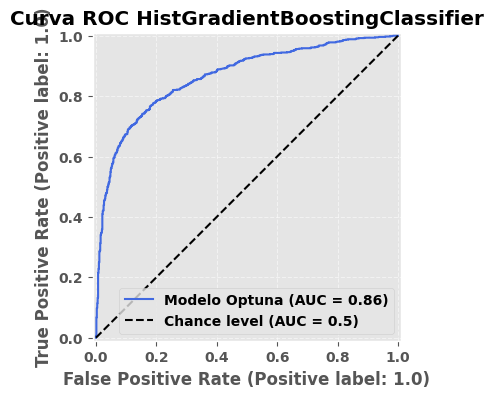

In [241]:
# ROC CHART - FINAL OPTUNA

# 1. Creamos la figura
fig, ax = plt.subplots(figsize=(6, 4))

# 2. Usamos el visualizador de sklearn apuntando a tu modelo optimizado
# No necesitamos .best_estimator_ si modelo_op es tu Pipeline/Modelo final
RocCurveDisplay.from_estimator(
    modelo_op, 
    val_x, 
    val_y, 
    ax=ax, 
    name='Modelo Optuna', 
    color='royalblue', 
    plot_chance_level=True # Dibuja la diagonal de azar (AUC = 0.5)
)

# 3. Personalización estética
# El nombre del algoritmo se extrae dinámicamente para el título
nombre_algoritmo = modelo_op.named_steps['algoritmo'].__class__.__name__
ax.set_title(f'Curva ROC {nombre_algoritmo}')
ax.grid(True, linestyle='--', alpha=0.5)

plt.show()

### INTERPRETABILIDAD: DALEX

DALEX (Descriptive mAchine Learning EXplanations) es una librería de explicabilidad que permite abrir la caja negra de modelos complejos como HistGradientBoosting. Opera en dos niveles:

- Global: analiza el comportamiento del modelo sobre todos los clientes e identifica qué variables tienen mayor impacto en las predicciones en general.
- Local: explica por qué el modelo asigna una probabilidad concreta a un cliente específico, desglosando la contribución positiva o negativa de cada variable sobre la predicción final.

Esto nos permite no solo saber que el modelo funciona bien (AUC 0.864), sino entender por qué toma cada decisión — algo crítico para poder trasladar los resultados al equipo de negocio y proponer acciones concretas.

#### Global

In [251]:
# ============================================================
# CREAR EL EXPLAINER
# ============================================================

explainer = dx.Explainer(
    model  = modelo_rs.best_estimator_.named_steps['algoritmo'],
    data   = val_x,
    y      = val_y.astype(float),
    label  = 'HistGradientBoosting'
)

# ============================================================
# GLOBAL — importancia de variables (para la presentación)
# ============================================================

vi = explainer.model_parts()
vi.plot(title='Importancia de variables')

Preparation of a new explainer is initiated

  -> data              : 1485 rows 6 cols
  -> target variable   : Parameter 'y' was a pandas.Series. Converted to a numpy.ndarray.
  -> target variable   : 1485 values
  -> model_class       : xgboost.sklearn.XGBClassifier (default)
  -> label             : HistGradientBoosting
  -> predict function  : <function yhat_proba_default at 0x0000020951011010> will be used (default)
  -> predict function  : Accepts pandas.DataFrame and numpy.ndarray.
  -> predicted values  : min = 0.00461, mean = 0.52, max = 1.0
  -> model type        : classification will be used (default)
  -> residual function : difference between y and yhat (default)
  -> residuals         : min = -1.0, mean = 0.000921, max = 0.991
  -> model_info        : package xgboost

A new explainer has been created!


#### Local

In [252]:
# ============================================================
# LOCAL — explicar un cliente concreto
# ============================================================

probas = modelo_rs.best_estimator_.predict_proba(val_x)[:, 1]

# Cliente con alta probabilidad
idx_alto = probas.argmax()
cliente_alto = val_x.iloc[[idx_alto]]

bd_alto = explainer.predict_parts(cliente_alto, type='break_down')
bd_alto.plot(title='Cliente con alta probabilidad de recompra')

# Cliente con baja probabilidad
idx_bajo = probas.argmin()
cliente_bajo = val_x.iloc[[idx_bajo]]

bd_bajo = explainer.predict_parts(cliente_bajo, type='break_down')
bd_bajo.plot(title='Cliente con baja probabilidad de recompra')

#### Aplicaciones de Dalex

- Segmentación de los clientes por probabilidad de recompra
- Aplicación a customer_id concreto

In [253]:
# Probabilidad de recompra para cada cliente
rfm['prob_recompra'] = modelo_rs.best_estimator_.predict_proba(x)[:, 1]

# Segmentar por probabilidad
rfm['segmento'] = pd.cut(rfm['prob_recompra'],
                          bins=[0, 0.3, 0.7, 1],
                          labels=['baja', 'media', 'alta'])

rfm['segmento'].value_counts()

segmento
alta     2360
baja     2182
media     405
Name: count, dtype: int64

Búsqueda de customer_id en el grupo de validación analizado y aplicación de Dalex a id concreto para su análisis

In [254]:
# Ver qué customer_ids hay disponibles en val_x
print(val_x.index.tolist()[:20])  # los primeros 20

[14576, 15795, 15838, 16289, 17137, 17551, 15203, 17592, 16204, 13604, 12530, 15716, 16661, 15786, 13554, 16808, 15542, 15872, 15501, 13565]


In [256]:
# Sacar un customer_id específico
customer_id_objetivo = 16289

if customer_id_objetivo in val_x.index:
    cliente_especifico = val_x.loc[[customer_id_objetivo]]
    bd = explainer.predict_parts(cliente_especifico, type='break_down')
    bd.plot(title=f'Cliente {customer_id_objetivo}')
else:
    print(f"El cliente {customer_id_objetivo} no se encuentra en val_x")

## AÑADIDOS


### CLUSTERING / K-Means sobre RFM

El modelo de clasificación nos dice con qué probabilidad va a volver cada cliente. El clustering nos dice quién es ese cliente — cómo se comporta, cuánto gasta, con qué frecuencia compra. Son dos preguntas distintas y complementarias. Aplicamos K-Means sobre las mismas variables escaladas que usó el modelo para que los dos análisis sean comparables y se puedan cruzar directamente.

#### Paso 1: Elbow method para elegir k óptimo

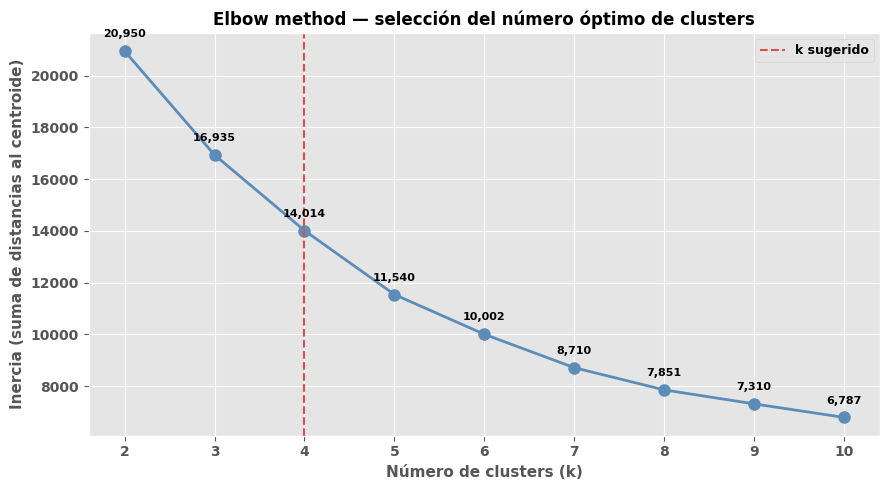

In [247]:
inercias = []
rango_k  = range(2, 11)

for k in rango_k:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(rfm_ss)
    inercias.append(km.inertia_)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(rango_k, inercias, marker='o', color='#5B8DB8', linewidth=2, markersize=8)

# Marcar el codo visualmente — ajusta el valor tras ver el gráfico
ax.axvline(x=4, color='#E24B4A', linestyle='--', linewidth=1.5, label='k sugerido')

for k, inercia in zip(rango_k, inercias):
    ax.annotate(f'{inercia:,.0f}', xy=(k, inercia),
                xytext=(0, 10), textcoords='offset points',
                ha='center', fontsize=8)

ax.set_xlabel('Número de clusters (k)', fontsize=11)
ax.set_ylabel('Inercia (suma de distancias al centroide)', fontsize=11)
ax.set_title('Elbow method — selección del número óptimo de clusters', fontsize=12)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

#### Paso 2 — K-Means

In [248]:
K_OPTIMO = 4  # ajusta tras ver el elbow

km_final = KMeans(n_clusters=K_OPTIMO, random_state=42, n_init=10)
rfm_ss['cluster'] = km_final.fit_predict(rfm_ss)

print(rfm_ss['cluster'].value_counts().sort_index())

cluster
0    1630
1     997
2    1269
3    1051
Name: count, dtype: int64


#### Paso 3 — Perfiles de cada cluster

=== PERFIL MEDIO POR CLUSTER (escala original) ===
                recency  numero_de_compras        monetary  dias_entre_pedidos  tasa_devolucion
cluster                                                                                        
0                269.85               1.33          377.50                6.74             0.01
1                188.33               4.53          998.25               42.81             0.36
2                120.46               3.84         1146.69              125.17             0.04
3                 47.98              19.47         7920.46               32.87             0.18


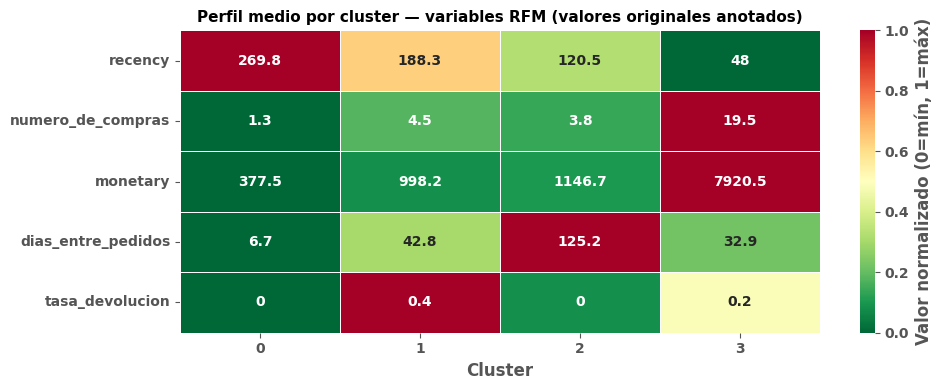

In [249]:
# Unir cluster a rfm_trans (escala original, legible)
rfm_perfil = rfm_trans.copy()
rfm_perfil['cluster'] = rfm_ss['cluster']

# Variables interpretables para el perfil
vars_perfil = ['recency', 'numero_de_compras', 'monetary',
               'dias_entre_pedidos', 'tasa_devolucion']

perfil = (rfm_perfil.groupby('cluster')[vars_perfil]
          .mean().round(2))

print("=== PERFIL MEDIO POR CLUSTER (escala original) ===")
print(perfil.to_string())

# Gráfico de perfiles — heatmap normalizado
perfil_norm = (perfil - perfil.min()) / (perfil.max() - perfil.min())

fig, ax = plt.subplots(figsize=(10, 4))
sns.heatmap(perfil_norm.T,
            annot=perfil.T.round(1),
            fmt='g',
            cmap='RdYlGn_r',
            linewidths=0.5,
            ax=ax,
            cbar_kws={'label': 'Valor normalizado (0=mín, 1=máx)'})
ax.set_title('Perfil medio por cluster — variables RFM (valores originales anotados)',
             fontsize=11)
ax.set_xlabel('Cluster')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

#### Paso 4 — Cruce cluster × segmento de probabilidad

=== DISTRIBUCIÓN DE SEGMENTOS POR CLUSTER ===
segmento  baja  media  alta  Total
cluster                           
0         1155    222   253   1630
1          483     53   461    997
2          479    103   687   1269
3           65     27   959   1051
Total     2182    405  2360   4947

=== PROBABILIDAD MEDIA DE RECOMPRA POR CLUSTER ===
             prob_media  n_clientes
cluster                            
0                  0.26        1630
1                  0.49         997
2                  0.58        1269
3                  0.91        1051


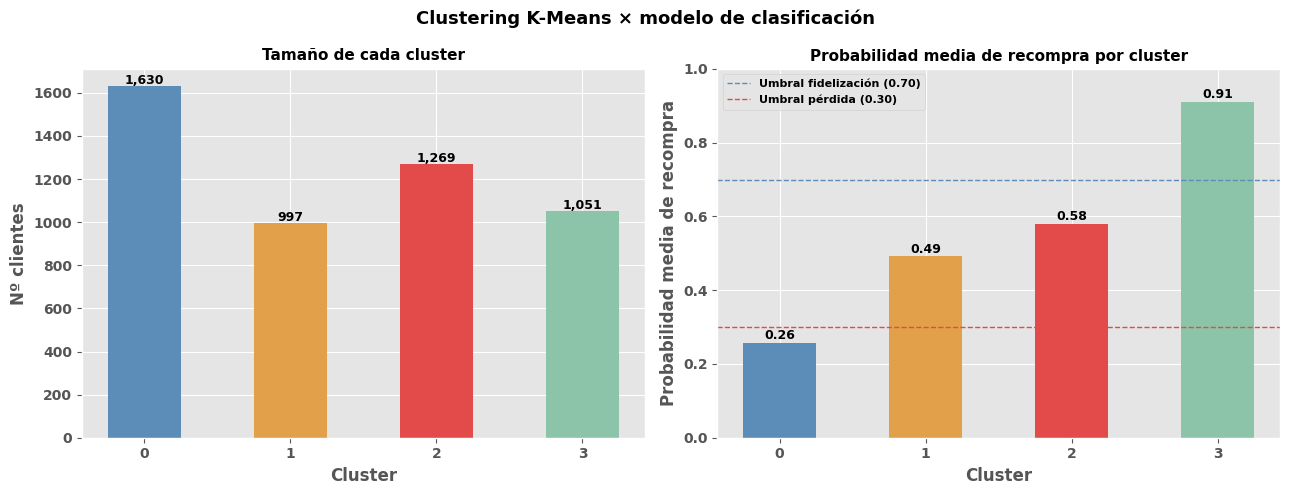

In [250]:
# Recalcular prob_recompra y segmento sobre rfm_ss (todos los clientes)
prob_recompra = modelo_rs.best_estimator_.predict_proba(rfm_ss.drop(columns='cluster'))[:, 1]

cruce = rfm_ss[['cluster']].copy()
cruce['prob_recompra'] = prob_recompra
cruce['segmento'] = pd.cut(cruce['prob_recompra'],
                            bins=[0, 0.3, 0.7, 1],
                            labels=['baja', 'media', 'alta'])

# Tabla cruzada
tabla_cruce = pd.crosstab(
    cruce['cluster'],
    cruce['segmento'],
    margins=True,
    margins_name='Total'
)
print("=== DISTRIBUCIÓN DE SEGMENTOS POR CLUSTER ===")
print(tabla_cruce)

# Probabilidad media por cluster
prob_por_cluster = (cruce.groupby('cluster')['prob_recompra']
                    .agg(['mean', 'count'])
                    .round(3)
                    .rename(columns={'mean': 'prob_media', 'count': 'n_clientes'}))
print("\n=== PROBABILIDAD MEDIA DE RECOMPRA POR CLUSTER ===")
print(prob_por_cluster)

# Gráfico
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

colores_cluster = ['#5B8DB8', '#E2A04A', '#E24B4A', '#8BC4A8',
                   '#B4B2A9', '#7B68EE', '#FF7F50', '#20B2AA'][:K_OPTIMO]

axes[0].bar(prob_por_cluster.index.astype(str),
            prob_por_cluster['n_clientes'],
            color=colores_cluster, width=0.5)
for i, (idx, row) in enumerate(prob_por_cluster.iterrows()):
    axes[0].text(i, row['n_clientes'] + 10,
                 f"{int(row['n_clientes']):,}", ha='center', fontsize=9)
axes[0].set_xlabel('Cluster')
axes[0].set_ylabel('Nº clientes')
axes[0].set_title('Tamaño de cada cluster', fontsize=11)

bars = axes[1].bar(prob_por_cluster.index.astype(str),
                   prob_por_cluster['prob_media'],
                   color=colores_cluster, width=0.5)
axes[1].axhline(y=0.7, color='#5B8DB8', linestyle='--',
                linewidth=1, label='Umbral fidelización (0.70)')
axes[1].axhline(y=0.3, color='#E24B4A', linestyle='--',
                linewidth=1, label='Umbral pérdida (0.30)')
for i, (idx, row) in enumerate(prob_por_cluster.iterrows()):
    axes[1].text(i, row['prob_media'] + 0.01,
                 f"{row['prob_media']:.2f}", ha='center', fontsize=9)
axes[1].set_xlabel('Cluster')
axes[1].set_ylabel('Probabilidad media de recompra')
axes[1].set_title('Probabilidad media de recompra por cluster', fontsize=11)
axes[1].set_ylim(0, 1)
axes[1].legend(fontsize=8)

plt.suptitle('Clustering K-Means × modelo de clasificación',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### ESTRATEGIA INTEGRAL DE CLIENTES: MODELO, CLUSTERING Y ACCIÓN COMERCIAL

#### 1. OPTIMIZACIÓN Y RENDIMIENTO DEL MODELO
Tras comparar múltiples algoritmos y optimizar mediante Random Search, el modelo final (HistGradientBoosting) ha alcanzado un AUC de 0.864 en validación. 
* **Interpretación:** El modelo es extremadamente robusto y tiene una capacidad superior para distinguir entre clientes que volverán y los que están en riesgo de fuga.
* **Eficiencia:** Las curvas de Ganancia y Lift confirman que podemos capturar el 75% de las ventas futuras contactando a menos de la mitad de nuestra base de datos, duplicando la eficiencia de cualquier contacto al azar.

---

#### 2. RADIOGRAFÍA ESTRATÉGICA DE LA CARTERA
No todos los clientes con la misma probabilidad deben tratarse igual. Hemos identificado 4 nichos de comportamiento más un segmento táctico de Invitados:

| Segmento | Perfil de Comportamiento | Salud (Prob. Recompra) | Diagnóstico de Negocio |
| :--- | :--- | :--- | :--- |
| ⭐ **VIPs (C3)** | Compra masiva y reciente. | Muy Alta (89%) | El motor de ingresos. Volverán sin ayuda. |
| ⏳ **Fieles (C2)** | Buenos tickets pero lentos. | Moderada (58%) | Clientes saludables pero "dormidos". |
| 🔄 **Indecisos (C1)** | Frecuentes pero con 36% de devolución. | Incierta (50%) | La logística y el producto dañan la rentabilidad. |
| ❄️ **Desconectados (C0)** | Una sola compra hace >9 meses. | Baja (27%) | Clientes prácticamente perdidos (Churn). |
| 👤 **Invitados (-1)** | Compradores anónimos. | N/A | Oportunidad de captación de datos (Leads). |

---

#### 3. PLAN DE ACCIÓN COMERCIAL
Basándonos en el cruce de la probabilidad predicha y el cluster, proponemos la siguiente matriz de actuación:

| Segmento | Acción Propuesta | Canal | Argumento de Negocio |
| :--- | :--- | :--- | :--- |
| **VIPs** | Programa de fidelización "Exclusivo". | Email / App VIP | No necesitan descuentos; necesitan trato preferente para maximizar su LTV. |
| **Fieles Espaciados** | Cupón de reactivación temporal. | Email / Retargeting | El objetivo es acortar el ciclo de compra y que no se olviden de la marca. |
| **Indecisos** | Encuesta de satisfacción y soporte. | Atención al Cliente | Hay que sanear la relación antes de venderles más; las devoluciones son un coste oculto. |
| **Desconectados** | Campaña "Última Oportunidad". | Social Ads / Email | Inversión mínima solo para liquidación de stock o recuperación de bajo coste. |
| **Invitados** | Incentivo por registro (Lead Magnet). | Pop-up Checkout | Convertir un anónimo en cliente identificado elimina el coste de captación futuro. |

---

#### 4. CONCLUSIÓN DE IMPACTO
La combinación de Clustering K-Means y Clasificación con Random Search permite una "cirugía de precisión" sobre la base de datos. Mientras que el modelo nos dice a quién priorizar, el clustering nos da el mensaje correcto. Esta estrategia asegura que el presupuesto de marketing se asigne donde el retorno es máximo, protegiendo a los mejores clientes y saneando los segmentos con fricciones operativas.